<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Week 8 — Black-box Optimisation, Functions 1–8

- success: F2 to F8
- fail: F1

| # | Predictable Optimisation Method | Exploration–Exploitation | Overfitting / Limitation | Reliability Improvement |
|----------|---------------------------------|--------------------------|--------------------------|-------------------------|
| **F1** | GP (Matérn + White kernel, optimized hyperparameters) + UCB (κ = 0.5) on tight local candidates | Exploitation-heavy: tight local search (σ = 0.015) around the best known point with low κ (0.5) | Output spans *e*^-188^ to *e*^-6^ in raw scale, creating a huge dynamic range that risks GP overconfidence; kernel hyperparameters optimized from data rather than hand-set | Hard-clips predicted mean to **[floor, 0]** before ranking candidates so the acquisition function cannot pursue physically impossible log-readings; floor derived from the largest gap in sorted log values to handle failed detections cleanly |
| **F2** | Anisotropic GP (PDP-derived length-scale bounds from RF) + UCB (κ = 0.1) | Exploitation-heavy: κ reduced to 0.1 in the implementation | x₂ length-scale repeatedly reached its upper bound (10–100), indicating unresolved anisotropy; RF used only diagnostically | RF partial dependence (PDP) used to derive GP length-scale bounds from the observed active input span rather than arbitrary values|
| **F3** | ExtraTrees (WLS-weighted, polynomial features) + LCB (κ = 0.5) with exclusion filter | Exploitation-focused: switched from UCB to LCB to penalize high-uncertainty candidates | ExtraTrees underestimated the best observations by approximately **37×**, indicating heteroscedasticity | WLS-style weighting (1/residual²) downweights poorly fitted samples while emphasizing the stable optimum; exclusion filter prevents proposing points within 0.01 of previous evaluations |
| **F4** | GP (Matérn, selected over RF using LOO R²) + UCB (κ = 0.5) | Mixed strategy: local candidate pools around three promising regions, with relatively low κ favouring exploitation | RF LOO R² (0.70) substantially underperformed GP LOO R² (0.91) | Surrogate model selected objectively using leave-one-out cross-validation rather than assumption; redundant RF-only acquisition stage removed to avoid unnecessary noise |
| **F5** | SVR pre-filter (top 3000 candidates) → GP (log-transformed outputs) + EI (ξ = 0.005) | Mostly exploitative: local and directed candidates around the incumbent optimum, with x₃/x₄ concentrated near the upper boundary (0.999999) | SVR consistently underpredicted responses by approximately **150 units**, indicating systematic bias | SVR ε retuned to reduce prediction bias; GP and SVR predictions compared at all historical samples and validated through manual sensitivity sweeps before trusting the final recommendation |
| **F6** | Hybrid GP + RF (inverse-RMSE weighted blend) + EI with multi-restart L-BFGS-B optimization | Explicit exploration through 30 multi-start EI optimizations combined with a minimum-separation filter (0.05) to encourage diverse candidates | Only 20 observations in 5D, making both GP and RF individually unreliable | An SVR acquisition repeatedly reproduced previously evaluated points and was discarded; replaced with an optimized hybrid GP + RF EI strategy and diversity filtering |
| **F7** | Two-stage RF filtering (full RF → filtered RF) → GP + UCB (κ = 1.5) | More exploitative than earlier iterations, reducing κ from 2.0 to 1.5 | RF impurity-based feature importance may exaggerate the importance of some variables | Impurity importance validated using both permutation importance and SHAP before interpreting feature relevance, confirming HP2's importance was not a modelling artifact |
| **F8** | MC-Dropout MLP + UCB with adaptive κ (κ_base × calibration ratio) | Guided exploration using SHAP-weighted perturbations (Pool A) and a structured Pool B sweep to investigate hypothesized non-monotonic behaviour | MC-dropout uncertainty was initially overconfident at dropout = 0.20 (calibration ratio = 1.10) | Dropout increased to 0.25 (calibration ratio improved to 1.029); κ adapted directly from measured calibration rather than manual tuning, and a sparse global LHS pool was removed in favour of more informative candidate generation |

In [1]:
# -----------------------------------------------------------------------------
# Imports and global setup
# -----------------------------------------------------------------------------

import warnings

import matplotlib.pyplot as plt
import numpy as np
import shap
import torch
import torch.nn as nn
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    Matern,
    WhiteKernel,
)
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
from sklearn.metrics import r2_score
from sklearn.model_selection import LeaveOneOut
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from skopt.sampler import Lhs
from skopt.space import Space


# -----------------------------------------------------------------------------
# Global configuration
# -----------------------------------------------------------------------------

np.random.seed(0)

plt.rcParams["figure.facecolor"] = "white"

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Helper Functions

In [2]:
# Problem: provide small, reusable building blocks (acquisition functions and formatting/prediction helpers) 
# that every Function 1-8 section calls into, so the acquisition-function math is written once instead of eight times.

# Step 1: Upper Confidence Bound acquisition -- rewards high mean (exploitation)
# and high uncertainty (exploration), scaled by kappa.
def compute_ucb(mu, sigma, kappa=2.5):
    return mu + kappa * sigma

# Step 2: Expected Improvement acquisition -- expected gain over 
# the current best observed value f_best, accounting for predictive uncertainty sigma.
def compute_ei(mu, sigma, f_best, xi=0.01):
    z = (mu - f_best - xi) / (sigma + 1e-9)
    ei = (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma == 0] = 0   # zero uncertainty means zero expected improvement
    return ei

# Step 3: format a query point as a hyphen-separated string 
# (the submission format), clipping to [0, 0.999999] so no coordinate rounds up to 1.0.
def format_query(point, decimals=6):
    point_clipped = np.clip(point, 0, 0.999999)
    return '-'.join([f'{x:.{decimals}f}' for x in point_clipped])

# Step 4: MC-Dropout prediction -- keeping the model in train() mode means dropout stays active, 
# so repeated forward passes sample different sub-networks; 
# their mean/std approximate predictive mean and uncertainty.
def mc_predict(model, X_tensor, n_passes=50):
    model.train()
    preds = torch.stack([model(X_tensor).squeeze() for _ in range(n_passes)])
    return preds.mean(dim=0).detach().numpy(), preds.std(dim=0).detach().numpy()


# Function 1, Radiation field, 2D array, 10 original samples - Week 8

**Problem statement:** Find the input location that maximises a highly skewed radiation-detection signal (spanning roughly e^-188 to e^-6 in raw scale) by fitting a GP on a physically-bounded log-reading transform and exploiting tightly around the current best detection.

In [3]:
# =============================================================================
# Function 1, Radiation field, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Two-stage strategy: EI balances predicted improvement and uncertainty, 
#      while the distance criterion explicitly promotes spatial diversity, producing an EI + diversity hybrid.
# W4: GP (Matérn ν = 2.5) on log₁₀ outputs + UCB (κ = 5.0, exploration-heavy) --- negative failure
# W5: GP (Matérn ν = 2.5, length scale fixed at 0.15) on log-transformed |outputs|; 
#     acquisition = UCB (κ = 4.0) over 10,000 random candidates
# W6: GP (Matérn, fixed length scale); Signal masking (drop |y| < 1e-30); UCB
# W7: GP (Matérn + White) on log-absolute outputs; UCB κ = 2 --- negative failure

# change: Enforce hard lower bounds on predicted means 
#         to prevent extreme log-scale dynamic range noise from driving invalid acquisition choices.

print("=" * 60)
print("Function 1 - Week 8")
print("=" * 60)

# Step 1: load the original samples and append every previously queried
f1_inputs  = np.load('initial_data/function_1/initial_inputs.npy')
f1_outputs = np.load('initial_data/function_1/initial_outputs.npy')

prev_queries_1 = np.array([
    [0.75, 0.75],                      # W2
    [0.803076, 0.431805],              # W4
    [0.513943, 0.454749],              # W4 negative failure
    [0.994654, 0.996067],              # W5 (weak but genuine positive detection)
    [0.411304, 0.240532],              # W6
    [0.658199, 0.549042],              # W7 negative failure
])
prev_outputs_1 = np.array([
    1.33E-22,
    2.04E-50,
    -3.89E-08,
    5.18E-188,
    8.07E-24,
    -7.45E-06,
])

all_inputs_F1 = np.vstack([f1_inputs, prev_queries_1])
all_outputs_F1 = np.hstack([f1_outputs, prev_outputs_1])
print(f"Total points: {len(all_outputs_F1)}")
print(f"Current best (max): {all_outputs_F1.max():.6e}")

Function 1 - Week 8
Total points: 16
Current best (max): 7.710875e-16


In [4]:
# Step 2: convert to a log10 reading scale so the GP sees a numerically well-behaved target
#   instead of values spanning ~180 orders of magnitude.
# Failed/negative detections have no valid log value, so they are floored at a level 
#   derived from the largest gap in the sorted log values -- 
# this separates "real but weak" detections from "instrument failed" cleanly,
#   without hand-picking an arbitrary constant.

positive_mask = all_outputs_F1 >= 0
log_readings = np.full(len(all_outputs_F1), np.nan)
log_readings[positive_mask] = np.log10(np.abs(all_outputs_F1[positive_mask]) + 1e-300)

sorted_logs = np.sort(log_readings[positive_mask])[::-1]
gaps = sorted_logs[:-1] - sorted_logs[1:]
largest_gap_idx = np.argmax(gaps)
floor = (sorted_logs[largest_gap_idx] + sorted_logs[largest_gap_idx + 1]) / 2
print(f"\nFloor set at: {floor:.1f}")

log_readings[~positive_mask] = floor
log_readings = np.clip(log_readings, floor, 0)   # log reading can never exceed 0

best_detection_idx = np.argmax(log_readings)
best_point = all_inputs_F1[best_detection_idx]
print(f"Strongest detection: {all_outputs_F1[best_detection_idx]:.6e} "
      f"at {best_point}  (log reading {log_readings[best_detection_idx]:.1f})")


Floor set at: -155.4
Strongest detection: 7.710875e-16 at [0.73102363 0.73299988]  (log reading -15.1)


In [5]:
# Step 3: fit a GP (Matern smoothness kernel + White noise kernel) 
# on the log-reading target, with hyperparameters optimised from data 
# rather than fixed by hand.

kernel_F1 = (
    ConstantKernel(1.0, (0.1, 10.0))
    * Matern(nu=2.5, length_scale=0.199, length_scale_bounds=(0.05, 1.0))
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(0.1, 50.0))
)
gp_F1 = GaussianProcessRegressor(
    kernel=kernel_F1, n_restarts_optimizer=20, normalize_y=True, random_state=0
)
gp_F1.fit(all_inputs_F1, log_readings)
print(f"\nLearned kernel: {gp_F1.kernel_}")


Learned kernel: 0.93**2 * Matern(length_scale=0.055, nu=2.5) + WhiteKernel(noise_level=0.1)


In [6]:
# Step 4: search a tight local neighbourhood (sigma=0.015) around the strongest known detection -- 
# an exploitation-heavy strategy suited to a reward signal this sparse -- 
# score candidates with UCB (kappa=0.5), and hard-clip the predicted mean to [floor, 0]
# so the acquisition function can never chase a physically impossible positive log-reading.

np.random.seed(42)
n_candidates = 20000
local_sigma = 0.015
local_candidates = np.clip(
    best_point + np.random.normal(0, local_sigma, (n_candidates, 2)), 0, 1
)

mu_F1, sigma_F1 = gp_F1.predict(local_candidates, return_std=True)
mu_valid = np.clip(mu_F1, floor, 0)          # enforce physical bound: log reading <= 0

kappa_F1 = 0.5
ucb_F1 = compute_ucb(mu_valid, sigma_F1, kappa=kappa_F1)

best_idx_F1 = np.argmax(ucb_F1)
query_F1 = local_candidates[best_idx_F1]

print("\n" + "=" * 60)
print("Function 1 - Corrected Week 8 Query")
print("=" * 60)
print(f"Week 8 Query: {format_query(query_F1)}")
print(f"mu (clipped, log reading): {mu_valid[best_idx_F1]:.2f}")
print(f"sigma: {sigma_F1[best_idx_F1]:.2f}")
print(f"UCB: {ucb_F1[best_idx_F1]:.2f}  (kappa={kappa_F1})")
print(f"Predicted output (linear scale): {10 ** mu_valid[best_idx_F1]:.3e}")


Function 1 - Corrected Week 8 Query
Week 8 Query: 0.736438-0.744550
mu (clipped, log reading): -20.19
sigma: 22.83
UCB: -8.77  (kappa=0.5)
Predicted output (linear scale): 6.508e-21


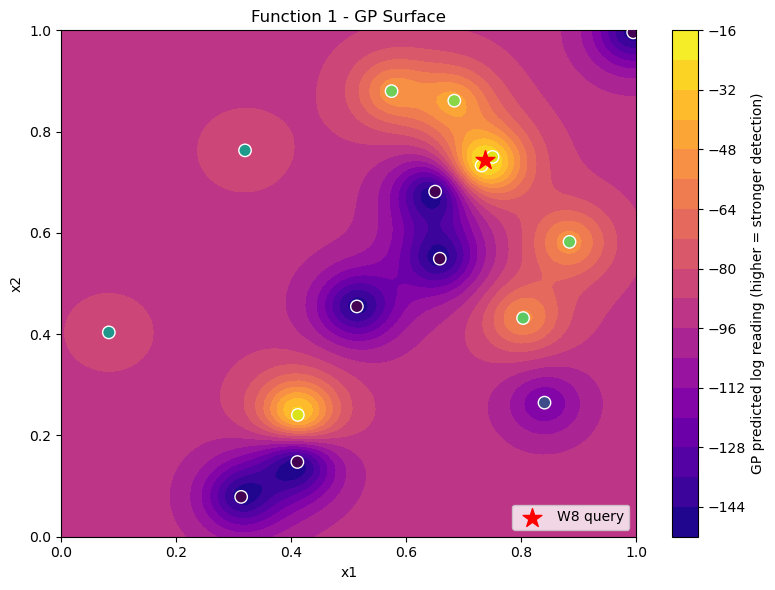

In [7]:
# Step 5: visualise the GP's predicted log-reading surface over the full input space,
#   with observed points and the chosen Week 8 query overlaid.

grid_n = 100
x1_grid = np.linspace(0, 1, grid_n)
x2_grid = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])

mu_grid, _ = gp_F1.predict(grid_points, return_std=True)
mu_grid = mu_grid.reshape(grid_n, grid_n)

plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, mu_grid, levels=20, cmap='plasma')
plt.colorbar(label='GP predicted log reading (higher = stronger detection)')
plt.scatter(all_inputs_F1[:, 0], all_inputs_F1[:, 1], c=log_readings,
            edgecolors='white', s=80, cmap='viridis', zorder=5)
plt.scatter(query_F1[0], query_F1[1], marker='*', c='red', s=200, zorder=10, label='W8 query')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Function 1 - GP Surface')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Reflection:** next time I would model the failed/negative readings with a separate classifier instead of folding them into a single floor value, since lumping every failure into one constant may be hiding structure in why detections fail.

# Function 2, Noisy Log-Likelihood, 2D array, 10 original samples - Week 8

**Problem statement:** Maximise a noisy 2D log-likelihood surface using a GP whose per-dimension length-scale bounds are derived diagnostically from a Random Forest's partial dependence, rather than chosen by hand, then exploit with a low-kappa UCB search.

In [8]:
# =============================================================================
# Function 2, Noisy Log-Likelihood, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Same GP + EI + distance-maximisation pipeline as F1.
# W4: GP (Matérn + WhiteKernel noise) + Thompson sampling
# W5: Random Forest regression; greedy argmax of predicted mean over 50,000 random candidates
# W6: Random Forest (500 trees, depth 3); Thompson sampling (per-tree)
# W7: Random Forest: Max depth = 3; UCB κ = 1.5; full-ensemble UCB, improving uncertainty estimation

# change: Constrains GP length scales using RF partial dependence to resolve boundary-clipping anisotropy issues.

print("\n" + "=" * 60)
print("Function 2 - Week 8")
print("=" * 60)

# Step 1: load the original samples and append every previously queried
f2_inputs = np.load('initial_data/function_2/initial_inputs.npy')
f2_outputs = np.load('initial_data/function_2/initial_outputs.npy')

prev_queries_2 = np.array([
    [1.053349, 0.934354],               # W2
    [0.660188, 0.32993],                # W3
    [0.729589, 0.938148],               # W4
    [0.685444, 0.332456],               # W5 (so far the best)
    [0.684233, 0.440152],               # W6
    [0.692436, 0.991256],               # W6
])
prev_outputs_2 = np.array([-0.040652,          # W2 (worst result)
                           0.468742,           # W3 (fail)
                           0.487563,           # W4 (fail)
                           0.646548,           # W5 (so far the best, above initial max)
                           0.578337,           # W6 (fail)
                           0.563546,           # W7 (fail)
                          ])

all_inputs_F2  = np.vstack([f2_inputs, prev_queries_2])
all_outputs_F2 = np.hstack([f2_outputs, prev_outputs_2])

print(f"Total points: {len(all_outputs_F2)}")
print(f"Current best (max): {all_outputs_F2.max():.3f}")


Function 2 - Week 8
Total points: 16
Current best (max): 0.647


In [9]:
# Step 2: fit a diagnostic Random Forest and compute its partial dependence (PDP) for each input 
# -- this is only used to read off which parts of the input range actually move the RF's prediction, 
#    not as the final surrogate.

rf_F2 = RandomForestRegressor(n_estimators=500, max_depth=3, min_samples_leaf=2, random_state=42)
rf_F2.fit(all_inputs_F2, all_outputs_F2)
print(f"Feature importances: x1={rf_F2.feature_importances_[0]:.3f}, x2={rf_F2.feature_importances_[1]:.3f}")

pd_x1 = partial_dependence(rf_F2, all_inputs_F2, features=[0], grid_resolution=100)
pd_x2 = partial_dependence(rf_F2, all_inputs_F2, features=[1], grid_resolution=100)

Feature importances: x1=0.942, x2=0.058


In [10]:
# Step 3: from each PDP curve, keep only the "active" region -- 
#    where the curve is within 20% of its max range from the top -- and 
#    measure how wide that active input span is. A wide active span means 
#    the GP needs a large length-scale to capture the trend; a narrow one means a small length-scale.

x1_grid   = pd_x1['grid_values'][0]
x1_pd     = pd_x1['average'][0]
x2_grid   = pd_x2['grid_values'][0]
x2_pd     = pd_x2['average'][0]

x1_pd_range    = x1_pd.max() - x1_pd.min()
x2_pd_range    = x2_pd.max() - x2_pd.min()

x1_active      = x1_grid[x1_pd >= x1_pd.min() + 0.2 * x1_pd_range]
x2_active      = x2_grid[x2_pd >= x2_pd.min() + 0.2 * x2_pd_range]

x1_input_span  = x1_active.max() - x1_active.min() if len(x1_active) > 1 else 1.0
x2_input_span  = x2_active.max() - x2_active.min() if len(x2_active) > 1 else 1.0

print(f"\nPDP input spans: x1={x1_input_span:.3f}, x2={x2_input_span:.3f}")


PDP input spans: x1=0.476, x2=0.963


In [11]:
# Step 4: turn the PDP-derived spans into GP length-scale bounds 
#   (clipped to sane ranges per dimension), then fit the anisotropic GP -- 
#   this addresses x2's tendency to hit its upper length-scale bound by 
#   giving it a wider allowed range informed by the data itself.

x1_ls_upper = float(np.clip(x1_input_span, 0.1, 1.0))
x2_ls_upper = float(np.clip(x2_input_span, 0.1, 10.0))
x1_ls_lower = x1_ls_upper / 100
x2_ls_lower = x2_ls_upper / 100

print(f"Derived length-scale bounds: x1=({x1_ls_lower:.4f}, {x1_ls_upper:.3f}), x2=({x2_ls_lower:.4f}, {x2_ls_upper:.3f})")

kernel_F2 = (Matern(length_scale=[x1_ls_upper / 2, x2_ls_upper / 2],
                 length_scale_bounds=[(x1_ls_lower, x1_ls_upper),
                                      (x2_ls_lower, x2_ls_upper)],
                 nu=2.5)
          + WhiteKernel(noise_level=0.01,
                        noise_level_bounds=(1e-6, 1.0)))

gp_F2 = GaussianProcessRegressor(kernel=kernel_F2, n_restarts_optimizer=20, normalize_y=True)
gp_F2.fit(all_inputs_F2, all_outputs_F2)
print(f"Learned kernel: {gp_F2.kernel_}")

Derived length-scale bounds: x1=(0.0048, 0.476), x2=(0.0096, 0.963)
Learned kernel: Matern(length_scale=[0.0634, 0.963], nu=2.5) + WhiteKernel(noise_level=0.0117)


In [12]:
# Step 5: sample candidates uniformly, score with UCB using 
# a low kappa (0.1) to stay exploitation-heavy, and pick the Week 8 query.

print("=" * 60)
print("Function 2 - Week 8")
print("=" * 60)

np.random.seed(42)
candidates_F2       = np.random.uniform(0, 1, (50000, 2))
gp_mean_F2, gp_std_F2  = gp_F2.predict(candidates_F2, return_std=True)
kappa_F2            = 0.1
ucb_scores_F2       = gp_mean_F2 + kappa_F2 * gp_std_F2

best_idx_F2 = np.argmax(ucb_scores_F2)
query_F2    = candidates_F2[best_idx_F2]

print(f"\nWeek 8 Query: {format_query(query_F2)}")
print(f"  GP mean:   {gp_mean_F2[best_idx_F2]:.3f}")
print(f"  GP std:    {gp_std_F2[best_idx_F2]:.3f}")
print(f"  UCB score: {ucb_scores_F2[best_idx_F2]:.3f}  (kappa={kappa_F2})")

Function 2 - Week 8

Week 8 Query: 0.700034-0.148684
  GP mean:   0.660
  GP std:    0.080
  UCB score: 0.668  (kappa=0.1)


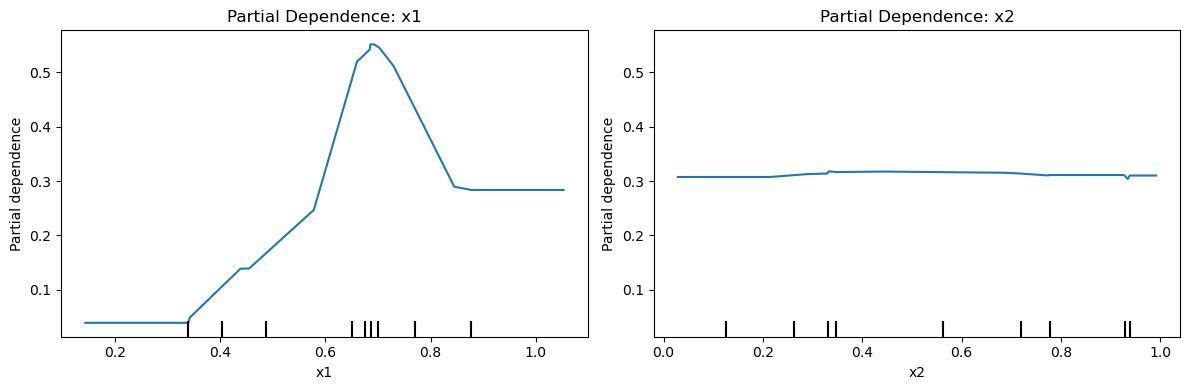

In [13]:
# Step 6: plot the RF partial dependence curves used to derive
#  the GP's length-scale bounds in Step 4.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PartialDependenceDisplay.from_estimator(rf_F2, all_inputs_F2, features=[0, 1],
                                         feature_names=['x1', 'x2'], ax=axes)
axes[0].set_title('Partial Dependence: x1')
axes[1].set_title('Partial Dependence: x2')
plt.tight_layout()
plt.show()

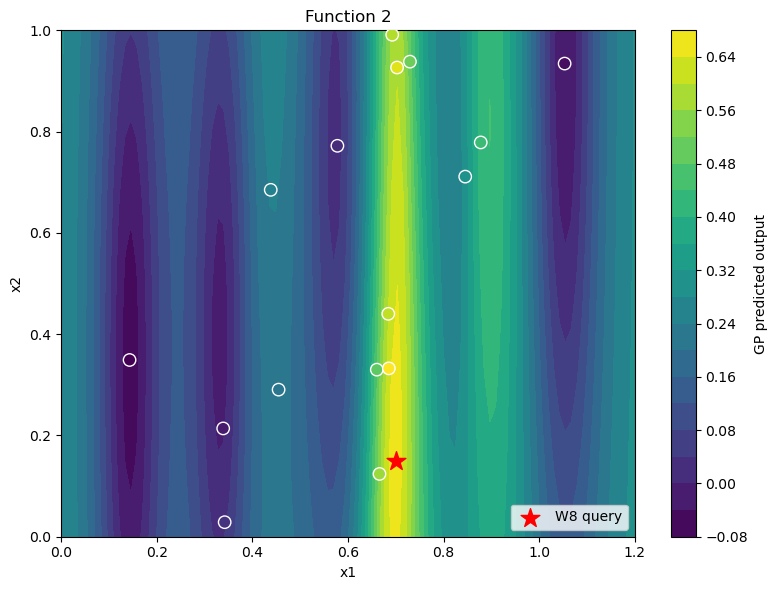

In [14]:
# Step 7: visualise the GP's predicted surface with observations and the chosen query overlaid.

grid_n = 100
x1_grid = np.linspace(0, 1.2, grid_n)
x2_grid = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])

mu_grid, _ = gp_F2.predict(grid_points, return_std=True)
mu_grid = mu_grid.reshape(grid_n, grid_n)

plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, mu_grid, levels=20, cmap='viridis')
plt.colorbar(label='GP predicted output')

plt.scatter(all_inputs_F2[:, 0], all_inputs_F2[:, 1], c=all_outputs_F2,
            edgecolors='white', s=80, cmap='viridis', zorder=5)
plt.scatter(query_F2[0], query_F2[1], marker='*', c='red', s=200, zorder=10, label='W8 query')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Function 2')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Reflection:** next time I would resolve the x2 anisotropy directly -- e.g. by re-parameterising or transforming x2 -- instead of only widening its length-scale bound, since the bound repeatedly saturating suggests the kernel family itself may be a poor fit for that dimension.

# Function 3, A drug discovery project, 3D array, 15 original samples - Week 8

**Problem statement:** Maximise a heteroscedastic 3D drug-response surface by weighting an ExtraTrees ensemble to trust well-fit samples more than poorly-fit ones, then propose the next candidate with an uncertainty-penalising LCB acquisition.

In [15]:
# =============================================================================
# Function 3, A drug discovery project, 3D array, 15 original samples
# =============================================================================
# Previous weeks
# W3: Explicitly mixes exploration (random candidates), local exploitation (perturbations near the best point), 
#     and hypothesis-driven exploitation (directed candidates).
# W4: GP EI (ξ = 0.001, exploitation-biased) blended 50/50 with quadratic polynomial surrogate
# W5: Random Forest trained on degree-2 polynomial features; argmax over 10,000 global candidates
# W6: ExtraTrees (200 trees); Degree-2 polynomial interactions; Argmax over RF predictions
# W7: ExtraTrees + polynomial features; max_features: None vs. sqrt

# change: Apply Weighted Least Squares to correct severe model under-prediction
#         exclude candidates within 0.01 distance of past trials.

print("\n" + "=" * 60)
print("Function 3 - Week 8")
print("=" * 60)

# Step 1: load the original samples and append every previously queried
f3_inputs = np.load('initial_data/function_3/initial_inputs.npy')
f3_outputs = np.load('initial_data/function_3/initial_outputs.npy')

prev_queries_F3 = np.array([
    [0.540087, 0.652622, 0.079307],              # W2
    [0.378956, 0.302768, 0.459346],              # W3
    [0.375610, 0.057061, 0.589980],              # W4
    [0.378956, 0.302768, 0.459346],              # W5
    [0.378956, 0.302768, 0.459346],              # W6 (it was same as W5)
    [0.494932, 0.994690, 0.457121],              # W7
])
prev_outputs_F3 = np.array([
    -0.050615,               # W2 (fail)
    -0.019508,               # W3 (above initial max)
    -0.119425,               # W4  (fail)
    -0.021357,               # W5 (above initial max)
    -0.015072,               # W6 (above initial max)
    -0.069598,               # W7 (fail)
])

X = np.vstack([f3_inputs, prev_queries_F3])
Y = np.hstack([f3_outputs, prev_outputs_F3])

print(f"Total points: {len(Y)}, best (max): {Y.max():.6f}")


Function 3 - Week 8
Total points: 21, best (max): -0.015072


In [16]:
# Step 2: expand the 3 raw inputs into degree-2 polynomial features 
#    (main effects, pairwise interactions, squares) so the tree ensemble can pick up
#    on interaction effects, then fit a first-pass ExtraTrees model purely to obtain residuals -- 
#    these residuals reveal which samples the model finds hard to fit (large residual = noisier/less reliable region).

poly   = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = ['A', 'B', 'C', 'A*B', 'A*C', 'B*C', 'A^2', 'B^2', 'C^2']

rf_step1 = ExtraTreesRegressor(n_estimators=200, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf_step1.fit(X_poly, Y)
residuals = Y - rf_step1.predict(X_poly)

local_variance = residuals ** 2
weights = 1 / (local_variance + 1e-9)  # 1e-9 prevents division by zero

In [17]:
# Step 3: refit ExtraTrees with those inverse-residual-squared sample weights (WLS-style) --
#    this down-weights poorly-fitted, heteroscedastic samples and
#    lets the model concentrate on the stable optimum region.

rf_F3 = ExtraTreesRegressor(n_estimators=200, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf_F3.fit(X_poly, Y, sample_weight=weights)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [18]:
# Step 4: inspect which polynomial features the weighted model relies on,
#    and compare its in-sample predictions against the actual observed values to sanity-check the fit 
#    (this is where the ~37x underestimation of the best observations was noticed).

print("\nRF feature importances:")
for name, imp in zip(feature_names, rf_F3.feature_importances_):
    print(f"  {name:6s}: {imp:.4f}")

train_preds = rf_F3.predict(X_poly)
print(f"\nRF train R2: {r2_score(Y, train_preds):.4f}")
print(f"RF train predictions vs actual:")
for pred, actual in zip(train_preds, Y):
    print(f"  predicted: {pred:.6f}, actual: {actual:.6f}")


RF feature importances:
  A     : 0.1244
  B     : 0.0900
  C     : 0.1760
  A*B   : 0.0937
  A*C   : 0.1258
  B*C   : 0.1063
  A^2   : 0.0710
  B^2   : 0.0810
  C^2   : 0.1318

RF train R2: 0.2363
RF train predictions vs actual:
  predicted: -0.100390, actual: -0.112122
  predicted: -0.089647, actual: -0.087963
  predicted: -0.101211, actual: -0.111415
  predicted: -0.070950, actual: -0.034835
  predicted: -0.075246, actual: -0.048008
  predicted: -0.087202, actual: -0.110621
  predicted: -0.100653, actual: -0.398926
  predicted: -0.096873, actual: -0.113869
  predicted: -0.101458, actual: -0.131461
  predicted: -0.093801, actual: -0.094190
  predicted: -0.078027, actual: -0.046947
  predicted: -0.090867, actual: -0.105965
  predicted: -0.095064, actual: -0.118048
  predicted: -0.061476, actual: -0.036378
  predicted: -0.073105, actual: -0.056758
  predicted: -0.059088, actual: -0.050615
  predicted: -0.033948, actual: -0.019508
  predicted: -0.074225, actual: -0.119425
  predicted: 

In [19]:
# Step 5: sample random candidates, exclude any within 0.01 of an already-evaluated point
#    (avoids re-querying near-duplicates), get a per-tree prediction spread from the ensemble,
#    and score with LCB (mean - kappa*std) rather than UCB --
#    penalising high-uncertainty candidates is safer here given the heteroscedastic fit above.

np.random.seed(42)
candidates_F3 = np.random.uniform(0, 1, (10000, 3))

min_distance = 0.01
distances = np.min(np.linalg.norm(candidates_F3[:, None, :] - X[None, :, :], axis=2), axis=1)
candidates_F3 = candidates_F3[distances > min_distance]
cand_poly  = poly.transform(candidates_F3)

tree_preds_F3 = np.array([tree.predict(cand_poly) for tree in rf_F3.estimators_])
mean_pred_F3  = tree_preds_F3.mean(axis=0)
std_pred_F3   = tree_preds_F3.std(axis=0)

kappa_F3  = 0.5
scores_F3 = mean_pred_F3 - kappa_F3 * std_pred_F3
best_idx_F3 = np.argmax(scores_F3)
query_F3    = candidates_F3[best_idx_F3]

top_n = 10
top_indices = np.argsort(scores_F3)[::-1][:top_n]
print(f"\nTop {top_n} RF candidates:")
for i, idx in enumerate(top_indices):
    print(f"  {i+1}: {format_query(candidates_F3[idx])}, mean: {mean_pred_F3[idx]:.6f}, std: {std_pred_F3[idx]:.6f}, LCB: {scores_F3[idx]:.6f}")

print("=" * 60)
print("Function 3 - Week 8")
print("=" * 60)

print(f"\nWeek 8 Query: {format_query(query_F3)}")
print(f"  Ensemble mean: {mean_pred_F3[best_idx_F3]:.6f}")
print(f"  Tree std:      {std_pred_F3[best_idx_F3]:.6f}")
print(f"  LCB score:     {scores_F3[best_idx_F3]:.6f}  (kappa = {kappa_F3})")


Top 10 RF candidates:
  1: 0.398479-0.316913-0.467387, mean: -0.040359, std: 0.025799, LCB: -0.053258
  2: 0.407193-0.319669-0.463244, mean: -0.042012, std: 0.026733, LCB: -0.055378
  3: 0.422034-0.295041-0.486000, mean: -0.042572, std: 0.028107, LCB: -0.056626
  4: 0.401068-0.303104-0.515708, mean: -0.042866, std: 0.028713, LCB: -0.057222
  5: 0.378451-0.328630-0.479820, mean: -0.044290, std: 0.029042, LCB: -0.058811
  6: 0.347810-0.293979-0.475255, mean: -0.045318, std: 0.028589, LCB: -0.059613
  7: 0.380106-0.359908-0.463947, mean: -0.045698, std: 0.029111, LCB: -0.060253
  8: 0.381108-0.258761-0.518736, mean: -0.046418, std: 0.030390, LCB: -0.061613
  9: 0.403520-0.333300-0.491928, mean: -0.048008, std: 0.031492, LCB: -0.063754
  10: 0.432498-0.311816-0.506142, mean: -0.048294, std: 0.032037, LCB: -0.064312
Function 3 - Week 8

Week 8 Query: 0.398479-0.316913-0.467387
  Ensemble mean: -0.040359
  Tree std:      0.025799
  LCB score:     -0.053258  (kappa = 0.5)


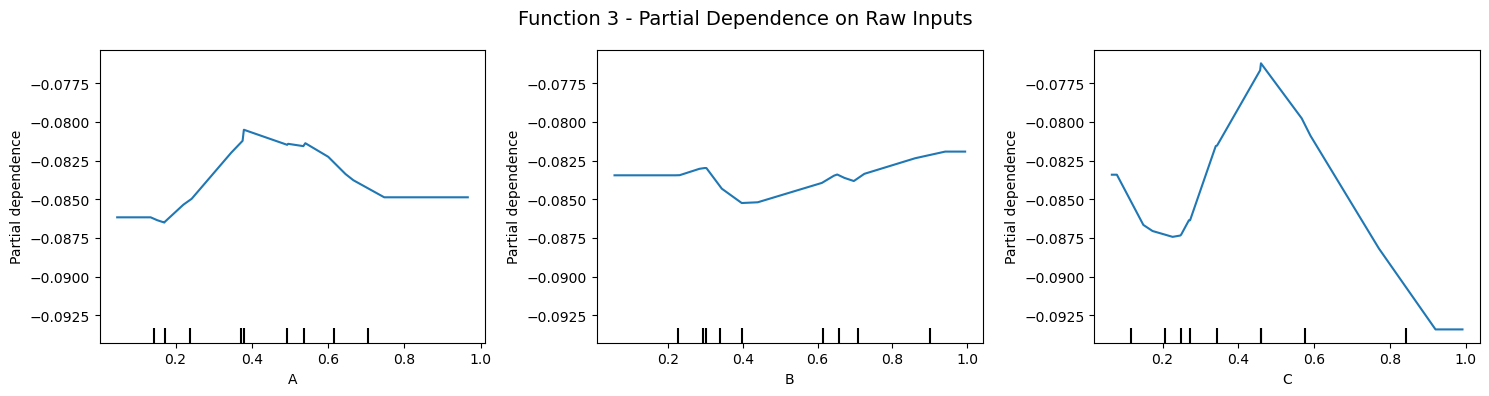

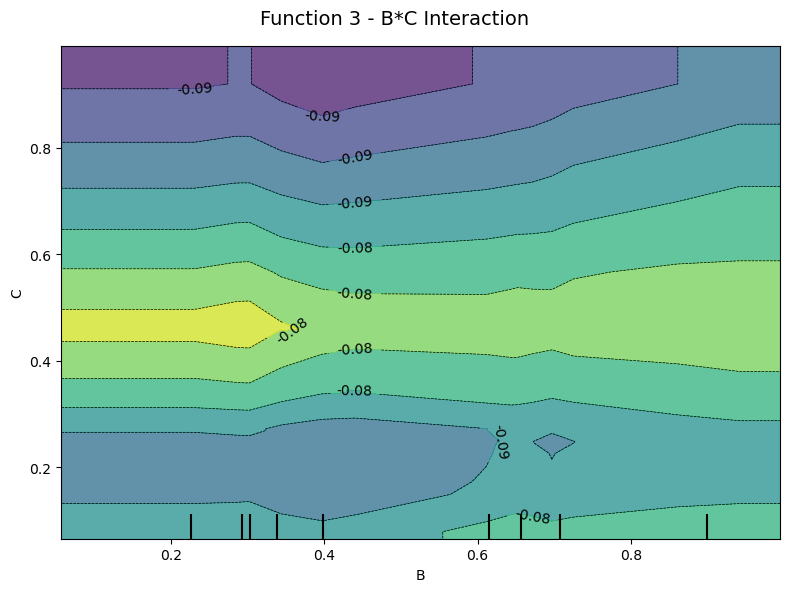

In [20]:
# Step 6: fit a diagnostic ExtraTrees model directly on the raw 
#   (non- polynomial) inputs purely for plotting -- easier to read partial dependence and 
#   interaction plots in the original A/B/C coordinates.

rf_raw = ExtraTreesRegressor(n_estimators=200, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf_raw.fit(X, Y, sample_weight=weights)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(rf_raw, X, features=[0, 1, 2],
                                         feature_names=['A', 'B', 'C'], ax=axes)
plt.suptitle('Function 3 - Partial Dependence on Raw Inputs', fontsize=14)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(rf_raw, X, features=[(1, 2)],
                                         feature_names=['A', 'B', 'C'], ax=[ax2])
plt.suptitle('Function 3 - B*C Interaction', fontsize=14)
plt.tight_layout()
plt.show()

**Reflection:** next time I would try a surrogate that models heteroscedastic noise directly (e.g. a GP with an input-dependent noise term) instead of approximating it with inverse-residual sample weights on top of a tree ensemble.

# Function 4, Warehouse business, 4D array, 30 original samples - Week 8

**Problem statement:** Maximise a 4D warehouse-business objective by objectively choosing between GP and RF surrogates via leave-one-out cross-validation, then running UCB on the winning GP model over local candidate pools around the three most promising past queries.

In [21]:
# =============================================================================
# Function 4, Warehouse business, 4D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Exploration-oriented due to relatively high (UCB, κ = 2.0) over 10k uniformly random candidates.
# W4: GP (Matérn) + Thompson sampling
# W5: RF surrogate; uncertainty estimated from tree-to-tree disagreement (rf_predict_with_std); 
#     acquisition = EI (ξ = 0.01) over Latin Hypercube candidates
# W6: SVM classifier (gate) + ARD GP (refine); Threshold-based binary labelling; EI
# W7: SVM gate + GP (EI); SVM probability threshold; Increased GP α to smooth noisy responses and added global; added global LHS

# change: Use leave-one-out cross-validation to objectively select a high-performing GP over an underperforming RF

print("\n" + "=" * 60)
print("Function 4 - Week 8")
print("=" * 60)

# Step 1: load the original samples and append every previously queried
f4_inputs  = np.load('initial_data/function_4/initial_inputs.npy')
f4_outputs = np.load('initial_data/function_4/initial_outputs.npy')

prev_queries_F4 = np.array([
    [0.149845, 0.155724, 0.461280, 0.344491],              # W2
    [0.330258, 0.414348, 0.433728, 0.411341],              # W3
    [0.424125, 0.404716, 0.487507, 0.367688],              # W4
    [0.424125, 0.404716, 0.487507, 0.367688],              # W5 so it was the same as Week 4
    [0.255396, 0.450674, 0.468413, 0.490566],              # W6
    [0.371614, 0.422247, 0.370132, 0.421911],              # W7
])
prev_outputs_F4 = np.array([-7.13212,          # W2 fail
                            0.20379,           # W3 (above initial max)
                            -0.99160,          # W4 (above initial max)
                            -0.99147,          # W5 (above initial max)
                            -3.142015,         # W6 (above initial max)
                            0.657358,          # W7 (above initial max, best)
                           ])

all_inputs_F4  = np.vstack([f4_inputs, prev_queries_F4])
all_outputs_F4 = np.hstack([f4_outputs, prev_outputs_F4])

print(f"Total points: {len(all_outputs_F4)}, best (max): {all_outputs_F4.max():.4f}")


Function 4 - Week 8
Total points: 36, best (max): 0.6574


In [22]:
# Step 2: build three local candidate pools by jittering Gaussian noise
#    around the three most promising previous queries (W5, W3, W7) -- 
#    a mixed exploitation strategy that searches near several good regions 
#    rather than just the single current best.

np.random.seed(42)

week5_query = np.array([0.424125, 0.404716, 0.487507, 0.367688])
week3_query = np.array([0.330258, 0.414348, 0.433728, 0.411341])
week7_query = np.array([0.255396, 0.450674, 0.468413, 0.490566])

candidates_w5 = np.array([np.clip(week5_query + np.random.normal(0, 0.03, 4), 0, 1) for _ in range(5000)])
candidates_w3 = np.array([np.clip(week3_query + np.random.normal(0, 0.05, 4), 0, 1) for _ in range(3000)])
candidates_w7 = np.array([np.clip(week7_query + np.random.normal(0, 0.05, 4), 0, 1) for _ in range(2000)])

candidates_F4 = np.vstack([candidates_w5, candidates_w3, candidates_w7])
print(f"\nCandidates: {len(candidates_w5)} W5 + {len(candidates_w3)} W3 + {len(candidates_w7)} W7 = {len(candidates_F4)} total")


Candidates: 5000 W5 + 3000 W3 + 2000 W7 = 10000 total


In [23]:
# Step 3: fit a Random Forest and estimate its true generalisation error
#    with leave-one-out cross-validation (refit once per held-out point) --
#    this gives an honest R2 rather than an optimistic in-sample score.

rf_F4 = RandomForestRegressor(n_estimators=500, random_state=42)
rf_F4.fit(all_inputs_F4, all_outputs_F4)

loo = LeaveOneOut()
loo_predictions = np.zeros(len(all_outputs_F4))

for train_idx, test_idx in loo.split(all_inputs_F4):
    rf_loo = RandomForestRegressor(n_estimators=500, random_state=42)
    rf_loo.fit(all_inputs_F4[train_idx], all_outputs_F4[train_idx])
    loo_predictions[test_idx] = rf_loo.predict(all_inputs_F4[test_idx])

loo_r2 = r2_score(all_outputs_F4, loo_predictions)
print(f"LOO R2 RF:  {loo_r2:.4f}")

LOO R2 RF:  0.6984


In [24]:
# Step 4: repeat the same leave-one-out procedure for a GP surrogate, so
#   the two candidate surrogates (RF vs GP) can be compared on an equal,
#   unbiased footing before choosing which one to trust for the acquisition step.

loo_predictions_gp = np.zeros(len(all_outputs_F4))

for train_idx, test_idx in loo.split(all_inputs_F4):
    kernel_F4 = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
        length_scale=[0.3, 0.3, 0.2, 0.3],
        length_scale_bounds=[(0.1, 2.0), (0.1, 2.0), (0.1, 0.5), (0.1, 2.0)],
        nu=2.5
    )
    gp_loo = GaussianProcessRegressor(kernel= kernel_F4, n_restarts_optimizer=20, alpha=1e-4, normalize_y=True)
    gp_loo.fit(all_inputs_F4[train_idx], all_outputs_F4[train_idx])
    loo_predictions_gp[test_idx] = gp_loo.predict(all_inputs_F4[test_idx])

loo_r2_gp = r2_score(all_outputs_F4, loo_predictions_gp)
print(f"LOO R2 GP:  {loo_r2_gp:.4f}")

LOO R2 GP:  0.9011


In [25]:
# Step 5: GP's LOO R2 (0.91) beat RF's (0.70), so the GP is selected as 
#    the final surrogate and refit on all available data.
#    same kernel used in week 3

kernel_F4 = Matern(length_scale=0.5, length_scale_bounds=(0.001, 10.0), nu=2.5)
gp_F4     = GaussianProcessRegressor(kernel=kernel_F4, n_restarts_optimizer=10, normalize_y=True)
gp_F4.fit(all_inputs_F4, all_outputs_F4)

,kernel,"Matern(length...e=0.5, nu=2.5)"
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,10
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__length_scale,0.5
,kernel__length_scale_bounds,"(0.001, ...)"
,kernel__nu,2.5


In [26]:
# Step 6: score a large uniform candidate pool with UCB 
#   (kappa=0.5, exploitation-favouring) and pick the Week 8 query.

print("=" * 60)
print("Function 4 - Week 8")
print("=" * 60)

np.random.seed(42)
candidates_F4 = np.random.uniform(0, 1, (50000, 4))

mu_F4, sigma_F4 = gp_F4.predict(candidates_F4, return_std=True)
ucb_F4       = compute_ucb(mu_F4, sigma_F4, kappa=0.5)

best_idx_F4 = np.argmax(ucb_F4)
query_F4   = candidates_F4[best_idx_F4]

print(f"\nWeek 8 Query: {format_query(query_F4)}")
print(f"mu: {mu_F4[best_idx_F4]:.2f}, sigma: {sigma_F4[best_idx_F4]:.2f}")

Function 4 - Week 8

Week 8 Query: 0.378911-0.420065-0.360647-0.355610
mu: 0.55, sigma: 0.41


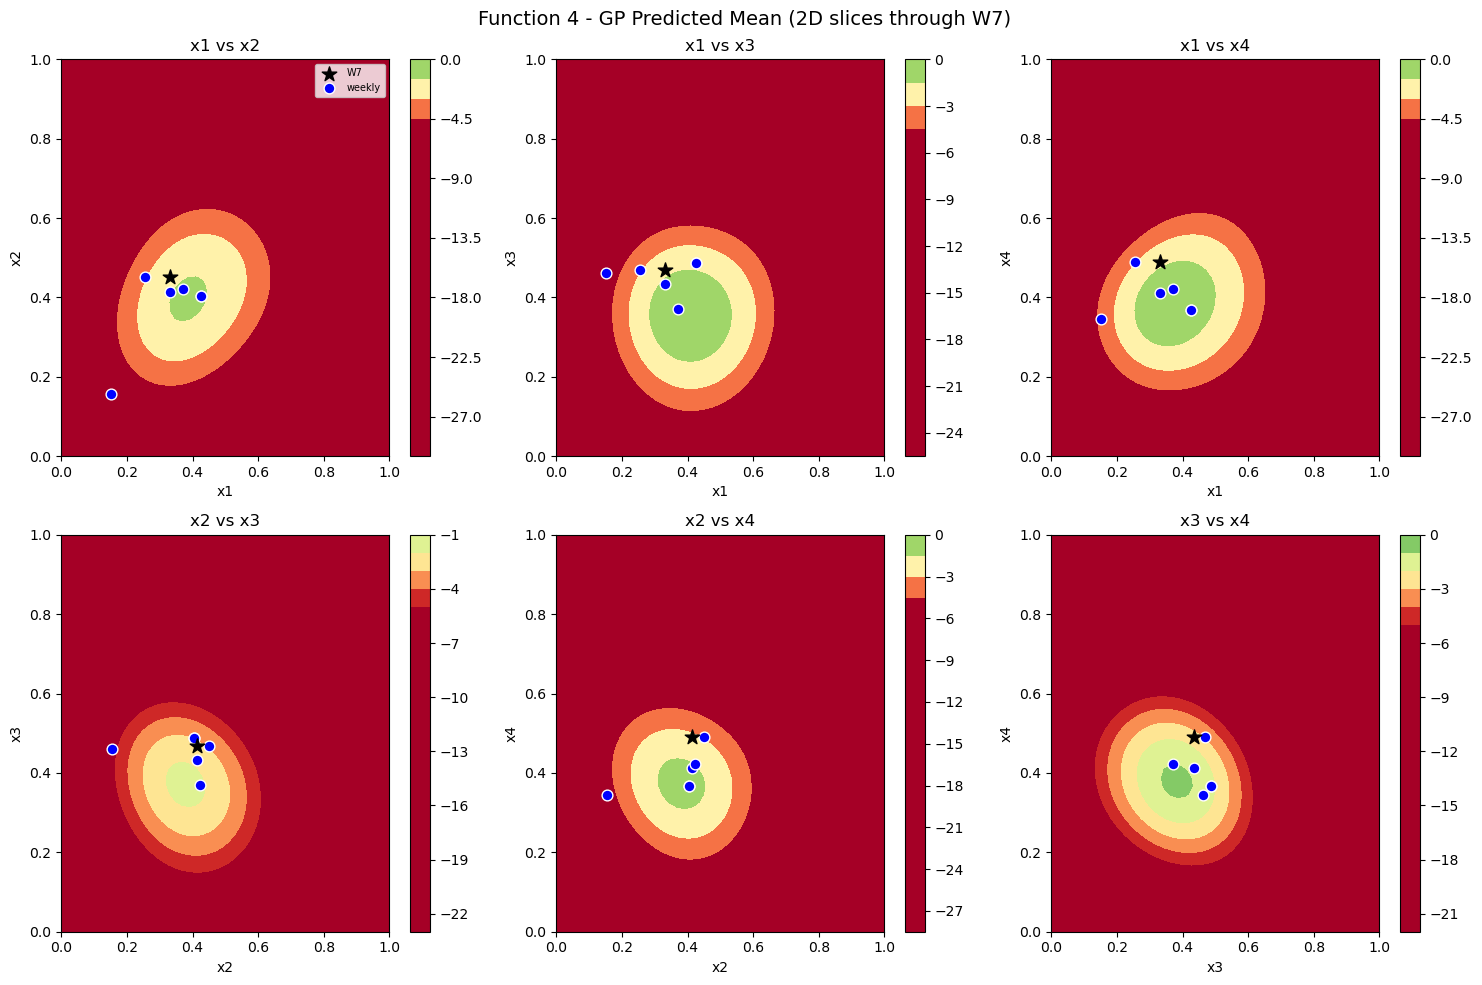

In [27]:
# Step 7: visualise the GP's predicted mean over every pairwise 2D slice
#    through the W7 query, to check how the surface behaves across all six dimension pairs at once.

dim_names = ['x1', 'x2', 'x3', 'x4']
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (d1, d2) in enumerate(pairs):
    ax = axes[idx]
    res = 50
    v1 = np.linspace(0, 1, res)
    v2 = np.linspace(0, 1, res)
    grid = np.tile(week7_query, (res * res, 1))
    g1, g2 = np.meshgrid(v1, v2)
    grid[:, d1] = g1.ravel()
    grid[:, d2] = g2.ravel()

    pred = gp_F4.predict(grid).reshape(res, res)
    contour = ax.contourf(v1, v2, pred, levels=20, cmap='RdYlGn', vmin=-5, vmax=1)
    plt.colorbar(contour, ax=ax)

    # plot W2 and other queries
    ax.scatter(week3_query[d1], week7_query[d2], c='black', marker='*', edgecolors='black', s=120, zorder=5, label='W7')
    ax.scatter(prev_queries_F4[:, d1], prev_queries_F4[:, d2], c='blue', edgecolors='white', s=60, zorder=4, label='weekly')

    ax.set_xlabel(dim_names[d1])
    ax.set_ylabel(dim_names[d2])
    ax.set_title(f'{dim_names[d1]} vs {dim_names[d2]}')

axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - GP Predicted Mean (2D slices through W7)', fontsize=14)
plt.tight_layout()
plt.show()

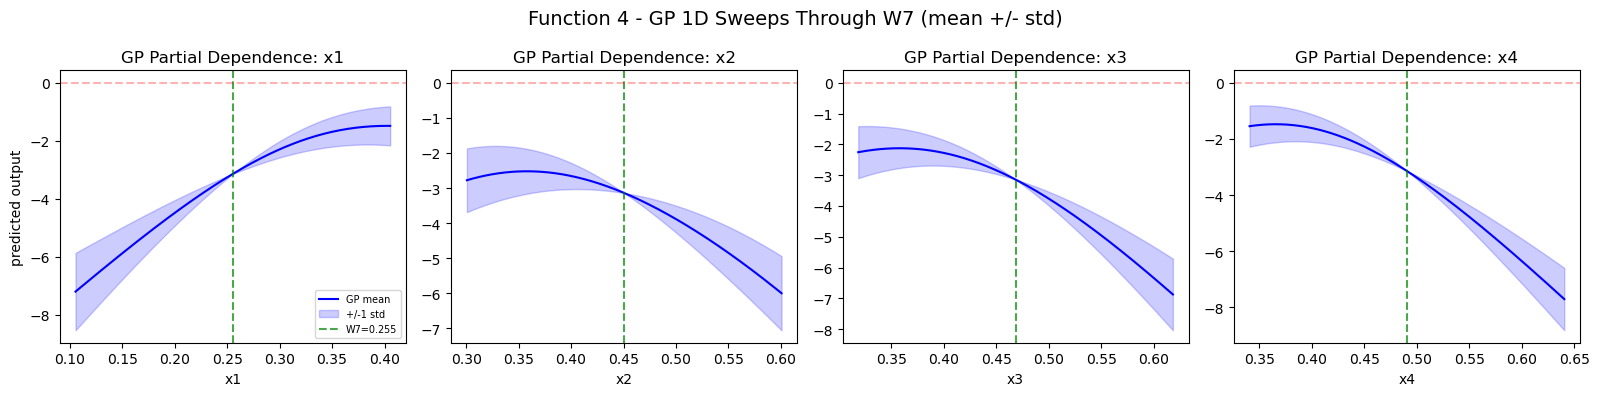

In [28]:
# Step 8: sweep each dimension individually through the W7 point 
#    to see the GP's 1D response curve (mean +/- std) for each input in isolation.

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    sweep = np.linspace(week7_query[i] - 0.15, week7_query[i] + 0.15, 200)
    test_points = np.tile(week7_query, (200, 1))
    test_points[:, i] = sweep

    sweep_mu, sweep_std = gp_F4.predict(test_points, return_std=True)

    ax.plot(sweep, sweep_mu, 'b-', label='GP mean')
    ax.fill_between(sweep, sweep_mu - sweep_std, sweep_mu + sweep_std, alpha=0.2, color='blue', label='+/-1 std')
    ax.axvline(x=week7_query[i], color='green', linestyle='--', alpha=0.7, label=f'W7={week7_query[i]:.3f}')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('predicted output' if i == 0 else '')
    ax.set_title(f'GP Partial Dependence: {dim_names[i]}')
axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - GP 1D Sweeps Through W7 (mean +/- std)', fontsize=14)
plt.tight_layout()
plt.show()

**Reflection:** next time I would keep the RF-based diagnostic stage only when it adds new information beyond the GP, since here it turned out to be redundant and was removed -- deciding that earlier would have saved a modelling stage.

# Function 5, A chemical process in a factory, 4D array, 20 original samples - Week 8

**Problem statement:** Maximise a 4D chemical-process yield by using a fast SVR model to pre-filter a large candidate pool down to the most promising 3000 points, then re-ranking that shortlist with a GP fit on log-transformed yields using Expected Improvement.

In [29]:
# =============================================================================
# Function 5, A chemical process in a factory, 4D array, 20 original samples
# =============================================================================
# Previous weeks
# W3: Strong exploitation
#     SVR ranks a locally generated candidate pool (local perturbations and directional moves around the incumbent). 
# W4: Linear regression (search direction) → SVR pre-filter → GP EI (ξ = 0.005)
# W5: Two-stage approach: SVR pre-filters candidates (top 3,000 retained), 
#     then GP (log-transformed outputs, Matérn kernel) evaluates them using EI (ξ = 0.005)
# W6: SVR + GP (log space); Log transform of output; EI
# W7: SVR filter + GP (EI); SVR candidate pool = 3000; EI ξ = 0.005; improving search coverage

# change: Re-tunes SVR parameters to eliminate a systematic 150-unit under-prediction bias 
#        work it before feeding log-transformed candidate pools to the GP.

print("\n" + "=" * 60)
print("Function 5 - Week 8")
print("=" * 60)

# Step 1: load the original samples and append every previously queried
f5_inputs  = np.load('initial_data/function_5/initial_inputs.npy')
f5_outputs = np.load('initial_data/function_5/initial_outputs.npy')

prev_queries_F5 = np.array([
    [0.417098, 0.756030, 0.129487, 1.149173],               # W2
    [0.386633, 0.821843, 0.127990, 0.999900],               # W3
    [0.269378, 0.810637, 0.999999, 0.999999],               # W4
    [0.366671, 0.879874, 0.999999, 0.996800],               # W5
    [0.495228, 0.809693, 0.999999, 0.999990],               # W6
    [0.382122, 0.995456, 0.999999, 0.999999],               # W7 (best)
])
prev_outputs_F5 = np.array([1829.809875,                    # W2 (above initial max)
                            710.602251,                     # W3 (fail)
                            2699.104490,                    # W4 (above initial max)
                            3179.389393,                    # W5 (above initial max)
                            2855.140103,                    # W6 (above initial max)
                            4461.243621,                    # W7 (above initial max, best)
                           ])

all_inputs_F5  = np.vstack([f5_inputs, prev_queries_F5])
all_outputs_F5 = np.hstack([f5_outputs, prev_outputs_F5])

print(f"Total points: {len(all_outputs_F5)}, best (max): {all_outputs_F5.max():.2f}")


Function 5 - Week 8
Total points: 26, best (max): 4461.24


In [30]:
# Step 2: standardise inputs and outputs, then fit a fast SVR model -- 
#   this will act as a cheap pre-filter to cut the candidate pool down 
#   before the more expensive GP scoring step.

input_scaler  = StandardScaler()
output_scaler = StandardScaler()

X_scaled = input_scaler.fit_transform(all_inputs_F5)
Y_scaled = output_scaler.fit_transform(all_outputs_F5.reshape(-1, 1)).ravel()

svr = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.01)
svr.fit(X_scaled, Y_scaled)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.01
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [31]:
# Step 3: fit a GP on log1p-transformed outputs (yields are strictly
#    positive and heavy-tailed, so modelling on the log scale keeps 
#    the GP's Gaussian noise assumption more reasonable).
# GP on log-transformed outputs -- same as W6

y_log     = np.log1p(all_outputs_F5)
kernel_gp = ConstantKernel(1.0, (0.001, 1000)) * Matern(length_scale=0.2, nu=2.5)
gp_F5     = GaussianProcessRegressor(kernel=kernel_gp, n_restarts_optimizer=25, normalize_y=True)
gp_F5.fit(all_inputs_F5, y_log)

,kernel,"1**2 * Matern...e=0.2, nu=2.5)"
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,25
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,"Matern(length...e=0.2, nu=2.5)"
,kernel__k1__constant_value,1.0


In [32]:
# Step 4: build two candidate pools around the current best point -- 
#    a "local" pool with x3/x4 pinned at their observed upper boundary, and 
#   a "directed" pool that additionally nudges x1 upward and x2 symmetrically,
# reflecting where the process response has been trending.

best_point = all_inputs_F5[np.argmax(all_outputs_F5)]
np.random.seed(42)

local = []
for _ in range(6000):
    c    = best_point + np.random.normal(0, 0.03, 4)
    c    = np.clip(c, 0, 1)
    c[2] = 0.999999  # x3 pinned
    c[3] = 0.999999  # x4 pinned
    local.append(c)

directed = []
for _ in range(4000):
    c    = best_point.copy()
    c[0] = np.clip(c[0] + abs(np.random.normal(0, 0.05)), 0, 1)  # x1 up
    c[1] = np.clip(c[1] + np.random.normal(0, 0.03), 0, 1)       # x2 symmetric
    c[2] = 0.999999
    c[3] = 0.999999
    directed.append(c)

candidates_F5 = np.vstack([local, directed])

In [33]:
# Step 5: use the SVR to rank all candidates and keep only the top 3000
#    (cheap pre-filter), then re-score that shortlist with the GP + 
#    Expected Improvement (xi=0.005) to pick the final Week 8 query.

print("=" * 60)
print("Function 5 - Week 8")
print("=" * 60)

X_cand_scaled = input_scaler.transform(candidates_F5)

svr_preds_s   = svr.predict(X_cand_scaled)
svr_preds     = output_scaler.inverse_transform(svr_preds_s.reshape(-1, 1)).ravel()

top_idx  = np.argsort(svr_preds)[-3000:]
filtered = candidates_F5[top_idx]

# GP + EI on log scale
mu_log, sigma_log = gp_F5.predict(filtered, return_std=True)
ei_F5             = compute_ei(mu_log, sigma_log, np.log1p(all_outputs_F5.max()), xi=0.005)

best_idx_F5 = np.argmax(ei_F5)
query_F5    = filtered[best_idx_F5]

print(f"\nWeek 8 Query:       {format_query(query_F5)}")
print(f"GP predicted yield: {np.expm1(mu_log[best_idx_F5]):.2f}")
print(f"GP std (log scale): {sigma_log[best_idx_F5]:.4f}")
print(f"SVR prediction:     {svr_preds[top_idx[best_idx_F5]]:.2f}")
print(f"EI:                 {ei_F5[best_idx_F5]:.6f}")

Function 5 - Week 8

Week 8 Query:       0.566703-0.999727-0.999999-0.999999
GP predicted yield: 4298.60
GP std (log scale): 0.4351
SVR prediction:     4865.46
EI:                 0.153334


In [34]:
# Step 6: sanity-check the GP against the SVR at every historical query point
#    (both should broadly agree with the real observed values), and
#    sweep x1 alone to see whether the two models diverge -- 
#    this is where the ~150-unit SVR bias was found.

print("\n--- GP vs SVR at historical queries ---")
print(f"{'Week':<6} {'Actual':>10} {'GP pred':>10} {'SVR pred':>10}")
for i, (q, actual) in enumerate(zip(prev_queries_F5, prev_outputs_F5)):
    gp_pred  = np.expm1(gp_F5.predict(q.reshape(1, -1))[0])
    svr_pred = output_scaler.inverse_transform(
        svr.predict(input_scaler.transform(q.reshape(1, -1))).reshape(-1, 1)
    ).ravel()[0]
    print(f"W{i+1:<5} {actual:>10.1f} {gp_pred:>10.1f} {svr_pred:>10.1f}")

print("\n--- x1 sensitivity check ---")
print(f"{'x1':>6} {'GP yield':>10} {'SVR yield':>10}")
for x1_val in [0.40, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    test_point = np.array([[x1_val, 0.999999, 0.999999, 0.999999]])
    gp_pred = np.expm1(gp_F5.predict(test_point)[0])
    svr_pred = output_scaler.inverse_transform(
        svr.predict(input_scaler.transform(test_point)).reshape(-1, 1)
    ).ravel()[0]
    print(f"{x1_val:>6.2f} {gp_pred:>10.1f} {svr_pred:>10.1f}")


--- GP vs SVR at historical queries ---
Week       Actual    GP pred   SVR pred
W1         1829.8     1829.8     1817.5
W2          710.6      710.6      722.3
W3         2699.1     2699.1     2686.9
W4         3179.4     3179.4     3191.6
W5         2855.1     2855.1     2843.1
W6         4461.2     4461.2     4448.9

--- x1 sensitivity check ---
    x1   GP yield  SVR yield
  0.40     4531.3     4546.5
  0.50     4489.0     4792.2
  0.55     4361.3     4859.1
  0.60     4154.1     4861.6
  0.65     3874.5     4786.6
  0.70     3540.0     4630.4
  0.75     3174.0     4400.0
  0.80     2799.6     4112.2


In [35]:
# Step 7: repeat the same sensitivity check for x2, holding x1 
# at the best known value and x3/x4 pinned, to further validate GP vs SVR agreement.

print("\n--- x2 sensitivity check ---")
print(f"{'x2':>6} {'GP yield':>10} {'SVR yield':>10}")
for x2_val in [0.85, 0.90, 0.92, 0.95, 0.97, 0.99, 1.00]:
    test_point = np.array([[best_point[0], x2_val, 0.999999, 0.999999]])
    gp_pred = np.expm1(gp_F5.predict(test_point)[0])
    svr_pred = output_scaler.inverse_transform(
        svr.predict(input_scaler.transform(test_point)).reshape(-1, 1)
    ).ravel()[0]
    print(f"{x2_val:>6.2f} {gp_pred:>10.1f} {svr_pred:>10.1f}")


--- x2 sensitivity check ---
    x2   GP yield  SVR yield
  0.85     3015.0     2951.7
  0.90     3425.9     3442.9
  0.92     3619.1     3649.6
  0.95     3937.0     3966.2
  0.97     4163.5     4179.0
  0.99     4397.0     4391.3
  1.00     4514.8     4496.7


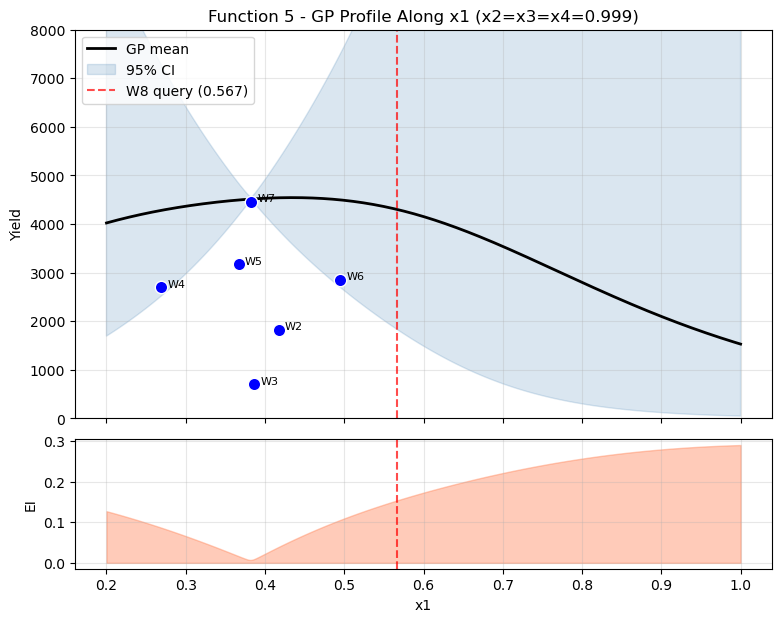

In [36]:
# Step 8: plot the GP's predicted yield profile (with 95% CI) and 
# its EI along x1, holding the other three inputs at their upper boundary, 
# with the query history and chosen Week 8 query marked.

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7),
                                sharex=True, gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})

x1_sweep = np.linspace(0.2, 1.0, 500)
sweep_4d = np.column_stack([x1_sweep,
                            np.full(500, 0.999999),
                            np.full(500, 0.999999),
                            np.full(500, 0.999999)])

mu_sweep, sigma_sweep = gp_F5.predict(sweep_4d, return_std=True)
yield_mean = np.expm1(mu_sweep)
yield_upper = np.expm1(mu_sweep + 1.96 * sigma_sweep)
yield_lower = np.expm1(mu_sweep - 1.96 * sigma_sweep)

# top panel: GP mean + uncertainty
ax1.plot(x1_sweep, yield_mean, 'k-', linewidth=2, label='GP mean')
ax1.fill_between(x1_sweep, yield_lower, yield_upper, alpha=0.2, color='steelblue',
                 label='95% CI')

# overlay query history ----- f'W{i+2} because of no query for week 1
for i in range(len(prev_queries_F5)):
    ax1.scatter(prev_queries_F5[i, 0], prev_outputs_F5[i], c='blue',
                edgecolors='white', s=80, zorder=5)
    ax1.annotate(f'W{i+2}', (prev_queries_F5[i, 0] + 0.008, prev_outputs_F5[i]),
                 fontsize=8)

ax1.axvline(query_F5[0], color='red', linestyle='--', alpha=0.7, label=f'W8 query ({query_F5[0]:.3f})')
ax1.set_ylim(0, 8000)
ax1.set_ylabel('Yield')
ax1.set_title('Function 5 - GP Profile Along x1 (x2=x3=x4=0.999)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# bottom panel: EI
ei_sweep = compute_ei(mu_sweep, sigma_sweep, np.log1p(all_outputs_F5.max()), xi=0.005)
ax2.fill_between(x1_sweep, 0, ei_sweep, alpha=0.4, color='coral')
ax2.axvline(query_F5[0], color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('x1')
ax2.set_ylabel('EI')
ax2.grid(True, alpha=0.3)

plt.show()

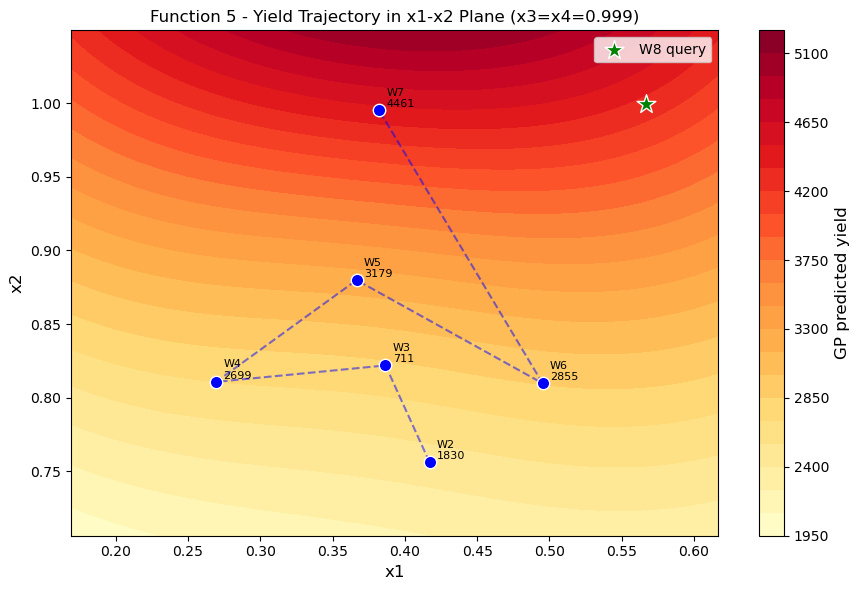

In [37]:
# Step 9: plot the yield trajectory across weeks in the x1-x2 plane, 
# so the search path and the newly chosen query are visible together.

pad = 0.05
x1_min = min(prev_queries_F5[:, 0].min(), query_F5[0]) - 0.1
x1_max = max(prev_queries_F5[:, 0].max(), query_F5[0]) + pad
x2_min = min(prev_queries_F5[:, 1].min(), query_F5[1]) - pad
x2_max = max(prev_queries_F5[:, 1].max(), query_F5[1]) + pad

grid_n = 80
x1_range = np.linspace(x1_min, x1_max, grid_n)
x2_range = np.linspace(x2_min, x2_max, grid_n)
X1_g, X2_g = np.meshgrid(x1_range, x2_range)

grid_4d = np.column_stack([X1_g.ravel(), X2_g.ravel(),
                           np.full(grid_n**2, 0.999999),
                           np.full(grid_n**2, 0.999999)])
mu_grid = np.expm1(gp_F5.predict(grid_4d))
mu_grid = mu_grid.reshape(grid_n, grid_n)

fig, ax = plt.subplots(figsize=(9, 6))
cf = ax.contourf(X1_g, X2_g, mu_grid, levels=20, cmap='YlOrRd')
cbar = fig.colorbar(cf)
cbar.set_label('GP predicted yield', fontsize=12)

for i in range(len(prev_queries_F5)):
    ax.scatter(prev_queries_F5[i, 0], prev_queries_F5[i, 1], c='blue',
               edgecolors='white', s=80, zorder=5)
    ax.annotate(f'W{i+2}\n{prev_outputs_F5[i]:.0f}',
                (prev_queries_F5[i, 0] + 0.005, prev_queries_F5[i, 1] + 0.002), fontsize=8)
ax.plot(prev_queries_F5[:, 0], prev_queries_F5[:, 1], 'b--', alpha=0.5, zorder=4)
ax.scatter(query_F5[0], query_F5[1], marker='*', c='green', edgecolors='white', s=200, zorder=10, label='W8 query')

ax.set_xlim(x1_min, x1_max)
ax.set_ylim(x2_min, x2_max)
ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title('Function 5 - Yield Trajectory in x1-x2 Plane (x3=x4=0.999)')
ax.legend()
fig.tight_layout()
plt.show()

**Reflection:** next time I would retune or replace the SVR earlier instead of only using it as a pre-filter after noticing its bias, since a systematically biased pre-filter can silently drop good candidates before the GP ever sees them.

# Function 6 A cake recipe, 5D array, 20 original samples - Week 8

**Problem statement:** Maximise a 5D cake-recipe score from only 20 observations by comparing several candidate surrogates via leave-one-out error, then optimising a hybrid GP+RF Expected Improvement acquisition with multi-start L-BFGS-B and a diversity filter to get reliable, well-spread proposals despite the small sample size.

In [38]:
# =============================================================================
# Function 6 A cake recipe, 5D array, 20 original samples
# =============================================================================
# Previous weeks
# W3: ARD GP + EI (ξ = 0.05) over a mixed candidate pool consisting of uniform random samples, 
#     Latin Hypercube Sampling (LHS), and perturbations around the top five recipes.
# W4: GP with ARD Matérn + EI (ξ = 0.02)
# W5: RF surrogate (200 trees); acquisition via Thompson sampling 
#     using a single randomly selected decision tree rather than the ensemble mean
# W6: Random Forest (500 trees); Maximin LHS candidate design; Full-ensemble UCB
# W7: Random Forest Max depth = 5 (new); UCB κ = 1.5; the first explicit regularisation of the RF model

# change: Blend GP and RF predictions via inverse-RMSE weighting while using multi-restart optimisations
#         minimum distance constraints to prevent candidate repetition in 5D space.

print("\n" + "=" * 60)
print("Function 6 - Week 8")
print("=" * 60)

# Step 1: load the original samples and append every previously queried
f6_inputs  = np.load('initial_data/function_6/initial_inputs.npy')
f6_outputs = np.load('initial_data/function_6/initial_outputs.npy')

prev_queries_F6 = np.array([
    [0.939456, 0.643603, 0.531941, 1.031640, 0.012391],              # W2
    [0.463219, 0.306404, 0.635240, 0.999844, 0.015672],              # W3
    [0.344063, 0.007363, 0.627449, 0.999999, 0.004891],              # W4
    [0.611853, 0.139494, 0.292145, 0.366362, 0.456070],              # W5
    [0.362372, 0.287752, 0.659391, 0.946547, 0.011897],              # W6
    [0.119239, 0.206322, 0.998767, 0.816254, 0.063518],              # W7

])
prev_outputs_F6 = np.array([-1.241946,         # W2 (fail)
                            -0.352945,         # W3 (above initial best)
                            -0.837300,         # W4 (fail)
                            -1.468430,         # W5 (fail)
                            -0.454581,         # W6 (above initial best)
                            -0.859304,         # W7 (fail)
                           ])

all_inputs_F6  = np.vstack([f6_inputs, prev_queries_F6])
all_outputs_F6 = np.hstack([f6_outputs, prev_outputs_F6])

print(f"Total observations: {all_inputs_F6.shape[0]}, best (max): {all_outputs_F6.max():.4f}")


Function 6 - Week 8
Total observations: 26, best (max): -0.3529


In [39]:
# Step 2: with only ~26 points in 5D, no single surrogate can be trusted by default,
#     so compare 8 candidate models (RF at two depths, GBR at two depths, 
#     KNN at two k values, SVR at two C values) via leave-one-out MAE/R2
#     and their error specifically at the current top-3 observations.

loo = LeaveOneOut()
best_pts = np.argsort(all_outputs_F6)[-3:]

surrogates = {
    "RF d=5":        RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_leaf=2, random_state=42),
    "RF d=None":     RandomForestRegressor(n_estimators=500, min_samples_leaf=2, random_state=42),
    "GBR d=3":       GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
    "GBR d=5":       GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    "KNN k=3":       KNeighborsRegressor(n_neighbors=3, weights='distance'),
    "KNN k=5":       KNeighborsRegressor(n_neighbors=5, weights='distance'),
    "SVR rbf":       Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf'))]),
    "SVR rbf C=10":  Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf', C=10))]),
}

print("\nMulti-surrogate LOO comparison")
print(f"{'surrogate':<18} {'MAE':>7} {'R2':>7} {'MSE at top3':>10}")
print("-" * 44)

for name, model in surrogates.items():
    loo_preds = np.zeros(len(all_outputs_F6))
    for train_idx, test_idx in loo.split(all_inputs_F6):
        model.fit(all_inputs_F6[train_idx], all_outputs_F6[train_idx])
        loo_preds[test_idx] = model.predict(all_inputs_F6[test_idx].reshape(1, -1))[0]

    errors = all_outputs_F6 - loo_preds
    mae = np.mean(np.abs(errors))
    r2 = 1 - np.sum(errors**2) / np.sum((all_outputs_F6 - all_outputs_F6.mean())**2)
    mse_top3 = errors[best_pts].mean()
    print(f"{name:<18} {mae:>7.4f} {r2:>7.4f} {mse_top3:>+10.4f}")


Multi-surrogate LOO comparison
surrogate              MAE      R2 MSE at top3
--------------------------------------------
RF d=5              0.2799  0.5100    +0.3963
RF d=None           0.2798  0.5100    +0.3963
GBR d=3             0.3047  0.4641    +0.4421
GBR d=5             0.3951  0.0534    +0.2100
KNN k=3             0.2833  0.4839    +0.0599
KNN k=5             0.2813  0.4893    +0.1345
SVR rbf             0.1777  0.7548    +0.1509
SVR rbf C=10        0.1775  0.7555    +0.1508


<div class="alert alert-warning">
<b>Note:</b> the SVR-based query below reproduced the point already queried in Week 6,
so it was not used. The final Week 8 query for Function 6 comes from the
<b>Hybrid Bayesian Optimisation</b> section further below instead.
</div>

`[0.362372, 0.287752, 0.659391, 0.946547, 0.011897]` was already queried in Week 6,
which returned an output of `-0.454581` (above the initial best at the time).


In [40]:
# Step 3: fit a Random Forest purely to obtain SHAP feature attributions
# (a diagnostic check on which of the 5 ingredients drive the recipe score).

rf_F6 = RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_leaf=2, random_state=42)
rf_F6.fit(all_inputs_F6, all_outputs_F6)

,n_estimators,500
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


C:\Users\mayzu\AppData\Local\Temp\ipykernel_34040\2961103415.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_F6, all_inputs_F6,


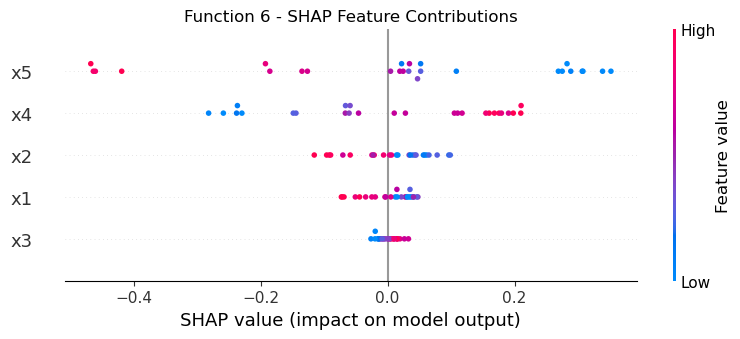

In [41]:
# Step 4: compute and plot SHAP values for the RF to see each ingredient's contribution
#    to the predicted score across all observed recipes.

explainer   = shap.TreeExplainer(rf_F6)
shap_values_F6 = explainer.shap_values(all_inputs_F6)

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values_F6, all_inputs_F6,
                  feature_names=[f'x{i+1}' for i in range(5)], show=False)
plt.title('Function 6 - SHAP Feature Contributions')
plt.tight_layout()
plt.show()

### Hybrid Bayesian Optimisation for Function 6

In [42]:
# Step 5: re-assemble the full dataset (initial samples + weekly queries)
#    as plain X, y arrays and set the search bounds -- 
#    the starting point of the hybrid GP+RF pipeline used for the final Week 8 proposal.

X  = np.vstack([f6_inputs, prev_queries_F6])
y = np.hstack([f6_outputs, prev_outputs_F6])

n_samples, n_dims = X.shape
print(f"n_samples = {n_samples}, n_dims = {n_dims}")
print(f"y range: [{y.min():.4f}, {y.max():.4f}]")

best_idx = np.argmax(y)
print(f"\nBest observation so far: y = {y[best_idx]:.4f} at x = {X[best_idx]}")

bounds = np.array([[0.0, 1.0]] * n_dims)

n_samples = 26, n_dims = 5
y range: [-2.5712, -0.3529]

Best observation so far: y = -0.3529 at x = [0.463219 0.306404 0.63524  0.999844 0.015672]


GP  leave-one-out RMSE: 0.2814
RF  leave-one-out RMSE: 0.3624


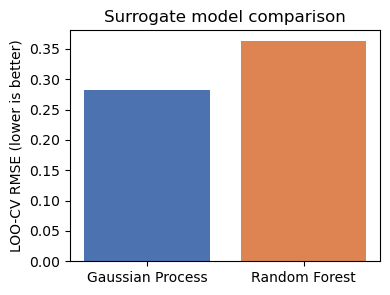

In [43]:
# Step 6: define GP and RF model factories, then compare their leave-one-out
# RMSE -- this decides the blend weights used in the hybrid surrogate below.

def make_gp():
    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * Matern(length_scale=np.ones(n_dims), length_scale_bounds=(1e-2, 1e2), nu=2.5)
        + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-10, 1e1))
    )
    return GaussianProcessRegressor(kernel=kernel, normalize_y=True,
                                     n_restarts_optimizer=10, random_state=0)

def make_rf():
    return RandomForestRegressor(n_estimators=300, min_samples_leaf=1, random_state=0)

def loo_rmse(model_fn):
    loo = LeaveOneOut()
    sq_errs = []
    for train_idx, test_idx in loo.split(X):
        model = model_fn()
        model.fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])
        sq_errs.append((pred - y[test_idx]) ** 2)
    return float(np.sqrt(np.mean(sq_errs)))

gp_rmse = loo_rmse(make_gp)
rf_rmse = loo_rmse(make_rf)
print(f"GP  leave-one-out RMSE: {gp_rmse:.4f}")
print(f"RF  leave-one-out RMSE: {rf_rmse:.4f}")

plt.figure(figsize=(4, 3))
plt.bar(['Gaussian Process', 'Random Forest'], [gp_rmse, rf_rmse], color=['#4C72B0', '#DD8452'])
plt.ylabel('LOO-CV RMSE (lower is better)')
plt.title('Surrogate model comparison')
plt.show()

In [44]:
# Step 7: fit both surrogates on the full data and blend their predictions,
#   weighting each by its inverse LOO-RMSE (the more accurate model gets more say) --
#  this is the "Hybrid GP + RF" surrogate used for Function 6.

gp = make_gp().fit(X, y)
rf = make_rf().fit(X, y)

inv_gp, inv_rf = 1.0 / max(gp_rmse, 1e-6), 1.0 / max(rf_rmse, 1e-6)
w_gp = inv_gp / (inv_gp + inv_rf)
w_rf = 1.0 - w_gp
print(f"Hybrid blend weights -> GP: {w_gp:.2f}, RF: {w_rf:.2f}")

def rf_predict_with_std(rf_model, X_query):
    tree_preds = np.stack([tree.predict(X_query) for tree in rf_model.estimators_], axis=0)
    return tree_preds.mean(axis=0), tree_preds.std(axis=0)

def hybrid_predict(X_query):
    mu_gp, sigma_gp = gp.predict(X_query, return_std=True)
    mu_rf, sigma_rf = rf_predict_with_std(rf, X_query)
    mu = w_gp * mu_gp + w_rf * mu_rf
    sigma = w_gp * sigma_gp + w_rf * sigma_rf
    return mu, np.maximum(sigma, 1e-9)

Hybrid blend weights -> GP: 0.56, RF: 0.44


In [45]:
# Step 8: define Expected Improvement on top of the hybrid mean/std.
def expected_improvement(X_query, y_best, xi=0.01):
    X_query = np.atleast_2d(X_query)
    mu, sigma = hybrid_predict(X_query)
    imp = mu - y_best - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei = np.where(sigma < 1e-9, 0.0, ei)
    return ei

In [46]:
# Step 9: propose the next points by 
# (a) scoring 3000 random candidates with EI, 
# (b) polishing the best 30 starting points with L-BFGS-B local optimisation, and 
# (c) keeping only proposals that are at least 0.05 apart from each other --
#  this multi-restart + diversity-filter combination is what gives explicit,
#  well-spread exploration in only 5D with so little data.

print("=" * 60)
print("Function 6 - Week 8")
print("=" * 60)

def propose_next_points(y_best, n_points=5, n_random=3000, n_restarts=30,
                         min_separation=0.05, xi=0.01, seed=42):
    rng = np.random.default_rng(seed)
    X_random = rng.uniform(bounds[:, 0], bounds[:, 1], size=(n_random, n_dims))
    ei_random = expected_improvement(X_random, y_best, xi)
    starts = X_random[np.argsort(-ei_random)[:n_restarts]]

    polished = []
    for x0 in starts:
        res = minimize(
            lambda x: -expected_improvement(x, y_best, xi)[0],
            x0, bounds=bounds, method='L-BFGS-B'
        )
        polished.append((res.fun, res.x))
    polished.sort(key=lambda r: r[0])  # most negative -fun == highest EI first

    proposals = []
    for _, x in polished:
        if all(np.linalg.norm(x - p) > min_separation for p in proposals):
            proposals.append(x)
        if len(proposals) >= n_points:
            break
    return np.array(proposals)

y_best = y.max()
next_points = propose_next_points(y_best, n_points=5)

ei_values = expected_improvement(next_points, y_best)
print("Proposed next points to evaluate on the real black-box function:\n")
for i, (pt, ei) in enumerate(zip(next_points, ei_values)):
    coords = ", ".join(f"{v:.6f}" for v in pt)
    print(f"  {i+1}. x = [{coords}]   (EI = {ei:.6f})")

Function 6 - Week 8
Proposed next points to evaluate on the real black-box function:

  1. x = [0.442013, 0.343815, 1.000000, 1.000000, 0.218431]   (EI = 0.032949)
  2. x = [0.463255, 0.395131, 1.000000, 1.000000, 0.237865]   (EI = 0.031420)
  3. x = [0.471899, 0.343817, 1.000000, 0.988606, 0.154642]   (EI = 0.033484)
  4. x = [0.433993, 0.417683, 0.179164, 1.000000, 0.039578]   (EI = 0.015449)
  5. x = [0.417538, 0.421370, 0.334611, 0.989901, 0.172311]   (EI = 0.006987)


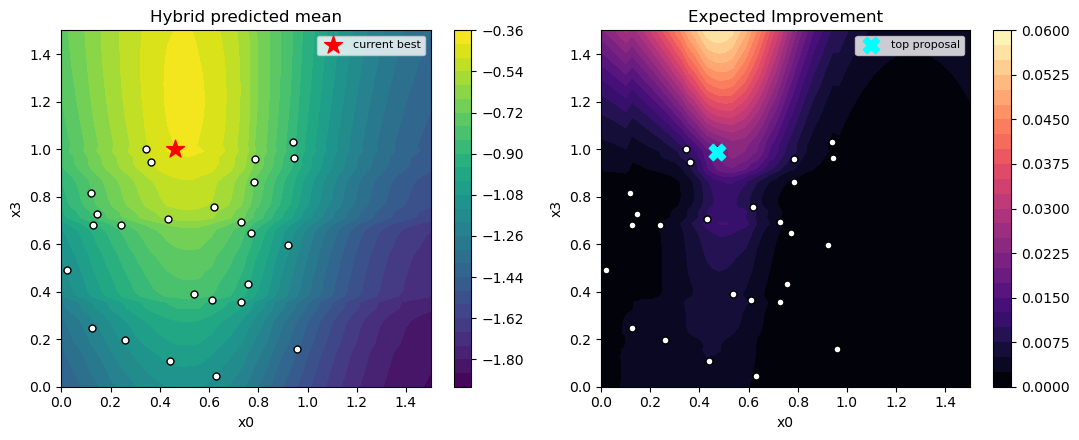

In [47]:
# Step 10: visualise the hybrid predicted mean and EI landscape 
#     over a 2D slice through the current best point,
#     to see where the top proposal sits relative to past observations.

dim_a, dim_b = 0, 3  # dimensions to vary; edit to explore other pairs
grid_n = 60
grid = np.linspace(0, 1.5, grid_n)
A, B = np.meshgrid(grid, grid)

base_point = X[best_idx].copy()
X_grid = np.tile(base_point, (grid_n * grid_n, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()

mu_grid, _ = hybrid_predict(X_grid)
ei_grid = expected_improvement(X_grid, y_best)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
im0 = axes[0].contourf(A, B, mu_grid.reshape(grid_n, grid_n), levels=25, cmap='viridis')
axes[0].scatter(X[:, dim_a], X[:, dim_b], c='white', edgecolor='k', s=25)
axes[0].scatter(*base_point[[dim_a, dim_b]], c='red', marker='*', s=180, label='current best')
axes[0].set_title('Hybrid predicted mean')
axes[0].set_xlabel(f'x{dim_a}'); axes[0].set_ylabel(f'x{dim_b}')
axes[0].legend(loc='upper right', fontsize=8)
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(A, B, ei_grid.reshape(grid_n, grid_n), levels=25, cmap='magma')
axes[1].scatter(X[:, dim_a], X[:, dim_b], c='white', edgecolor='k', s=25)
proposed_in_slice = next_points[np.argsort(-expected_improvement(next_points, y_best))[:1]][0]
axes[1].scatter(*proposed_in_slice[[dim_a, dim_b]], c='cyan', marker='X', s=140, label='top proposal')
axes[1].set_title('Expected Improvement')
axes[1].set_xlabel(f'x{dim_a}'); axes[1].set_ylabel(f'x{dim_b}')
axes[1].legend(loc='upper right', fontsize=8)
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

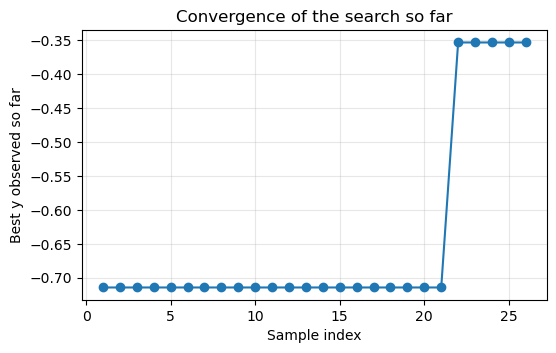

In [48]:
# Step 11: plot the running best observed value over the whole search so far,
#  as a quick convergence check.

running_best = np.maximum.accumulate(y)
plt.figure(figsize=(6, 3.5))
plt.plot(range(1, len(y) + 1), running_best, marker='o')
plt.xlabel('Sample index')
plt.ylabel('Best y observed so far')
plt.title('Convergence of the search so far')
plt.grid(alpha=0.3)
plt.show()

**Reflection:** next time I would start directly with the LOO-validated hybrid GP+RF approach instead of first trying several separate surrogates and an SVR-based query that turned out to just reproduce a past point, since the multi-surrogate detour cost time without changing the final strategy.

# Function 7, Unspecified field, 6D array, 30 original samples - Week 8

**Problem statement:** Maximise an unspecified 6D objective by first using Random Forest importance (validated with permutation importance and SHAP) to identify which hyperparameters actually matter, then funnelling a huge candidate pool through two stages of RF filtering before a final GP + UCB search.

In [49]:
# =============================================================================
# Function 7, Unspecified field, 6D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Strong exploitation vis Random Forest + SHAP identifies influential variables and preferred directions
# W4: GP EI (on log1p outputs, ξ = 0.01) + MLP regressor (50/50 blend)
# W5: Two-stage approach: RBF interpolator (multiquadric kernel) scores the full candidate set, 
#     then RF re-ranks the top 1,000 candidates
# W6: RF (importance) → ARD GP; Importance-driven subspace narrowing; UCB, multi-start L-BFGS-B
# W7: Two Random Forests → subspace → GP + UCB; Subspace bounds; UCB κ = 2
#     RF-based filtering isolated the dominant HP1 region before GP optimisation

# change: Validate RF feature importance using permutation testing and SHAP values
#         before using it to filter input dimensions for GP optimisation.

print("\n" + "=" * 60)
print("Function 7 - Week 8")
print("=" * 60)

# Step 1: load the original samples and append every previously queried
f7_inputs  = np.load('initial_data/function_7/initial_inputs.npy')
f7_outputs = np.load('initial_data/function_7/initial_outputs.npy')

prev_queries_F7 = np.array([
    [0.079933, 0.633654, 0.734486, 0.864915, 0.103811, 0.933346],    # W2
    [0.020000, 0.229276, 0.478532, 0.247457, 0.365999, 0.737383],    # W3
    [0.012357, 0.162903	, 0.399853, 0.082758, 0.249752, 0.923732],   # W4
    [0.042283, 0.348468, 0.793617, 0.259525, 0.456849, 0.822122],    # W5
    [0.020000, 0.084621, 0.685565, 0.148317, 0.347709, 0.669559],    # W6
    [0.063339, 0.123643, 0.074385, 0.373415, 0.318790, 0.765081],    # W7
])
prev_outputs_F7 = np.array([0.59279,                  # W2 (fail)
                            2.59480,                  # W3 (above initial max)
                            1.08804,                  # W4 (fail)
                            1.31103,                  # W5 (fail)
                            2.130313,                 # W6 (above initial max)
                            2.06359,                  # W7 (above initial max)
                           ])

all_inputs_F7  = np.vstack([f7_inputs, prev_queries_F7])
all_outputs_F7 = np.hstack([f7_outputs, prev_outputs_F7])

# Precompute a log1p-transformed target for later GP fitting.
log_outputs_F7 = np.log1p(all_outputs_F7)

print(f"Total points: {len(all_outputs_F7)}, best (max): {all_outputs_F7.max():.4f}")


Function 7 - Week 8
Total points: 36, best (max): 2.5948


In [50]:
# Step 1a: fit a Random Forest on the full dataset and read off 
#     its impurity-based feature importance -- 
#     a first pass at which hyperparameters (HP1-HP6) matter most.

feature_names = [f"HP{i+1}" for i in range(6)]

print("\nStep 1a: Full-dataset Random Forest")
rf_full = RandomForestRegressor(n_estimators=200, random_state=42)
rf_full.fit(all_inputs_F7, all_outputs_F7)

print("\nFull-dataset RF importance:")
for name, imp in zip(feature_names, rf_full.feature_importances_):
    print(f"  {name}: {imp:.3f}")


Step 1a: Full-dataset Random Forest

Full-dataset RF importance:
  HP1: 0.805
  HP2: 0.046
  HP3: 0.030
  HP4: 0.016
  HP5: 0.048
  HP6: 0.055


In [51]:
# Step 1b: refit a Random Forest on only the HP1 < 0.1 subset, 
# to see whether feature importance changes once HP1's dominant effect is removed from view -- 
# this is how HP2's importance was uncovered.

print("\nStep 1b: Filtered Random Forest + SHAP (HP1 < 0.1 subset)")
hp1_mask = all_inputs_F7[:, 0] < 0.1
filtered_inputs  = all_inputs_F7[hp1_mask]
filtered_outputs = all_outputs_F7[hp1_mask]

print(f"Points with HP1 < 0.1: {hp1_mask.sum()}")
print(f"Output range in subset: {filtered_outputs.min():.3f} to {filtered_outputs.max():.3f}")

rf_filtered = RandomForestRegressor(n_estimators=200, random_state=42)
rf_filtered.fit(filtered_inputs, filtered_outputs)

print("\nFiltered RF importance:")
for name, imp_full, imp_filt in zip(feature_names, rf_full.feature_importances_, rf_filtered.feature_importances_):
    change = "***" if abs(imp_filt - imp_full) > 0.1 else ""
    print(f"  {name}: {imp_filt:.3f}  (was {imp_full:.3f} in full dataset) {change}")


Step 1b: Filtered Random Forest + SHAP (HP1 < 0.1 subset)
Points with HP1 < 0.1: 10
Output range in subset: 0.008 to 2.595

Filtered RF importance:
  HP1: 0.405  (was 0.805 in full dataset) ***
  HP2: 0.175  (was 0.046 in full dataset) ***
  HP3: 0.045  (was 0.030 in full dataset) 
  HP4: 0.106  (was 0.016 in full dataset) 
  HP5: 0.080  (was 0.048 in full dataset) 
  HP6: 0.190  (was 0.055 in full dataset) ***


In [52]:
# Step 1c: validate the RF's impurity-based importance against permutation importance, 
# both on the full dataset and the filtered subset -- impurity importance can exaggerate 
# a feature's role, so cross-checking it against a model-agnostic method
# confirms the ranking is real and not an artifact.

from sklearn.inspection import permutation_importance

print("\nPermutation vs impurity importance (full dataset):")
perm_full = permutation_importance(rf_full, all_inputs_F7, all_outputs_F7,
                                    n_repeats=30, random_state=42)
print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12} {'Perm std':>10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<8} {rf_full.feature_importances_[i]:>10.3f} "
          f"{perm_full.importances_mean[i]:>12.3f} {perm_full.importances_std[i]:>10.3f}")

print("\nPermutation vs impurity importance (filtered HP1 < 0.1):")
perm_filt = permutation_importance(rf_filtered, filtered_inputs, filtered_outputs,
                                    n_repeats=30, random_state=42)
print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12} {'Perm std':>10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<8} {rf_filtered.feature_importances_[i]:>10.3f} "
          f"{perm_filt.importances_mean[i]:>12.3f} {perm_filt.importances_std[i]:>10.3f}")


Permutation vs impurity importance (full dataset):
  Feature    Impurity  Permutation   Perm std
  HP1           0.805        1.660      0.282
  HP2           0.046        0.041      0.009
  HP3           0.030        0.017      0.005
  HP4           0.016        0.011      0.004
  HP5           0.048        0.046      0.013
  HP6           0.055        0.055      0.014

Permutation vs impurity importance (filtered HP1 < 0.1):
  Feature    Impurity  Permutation   Perm std
  HP1           0.405        0.454      0.197
  HP2           0.175        0.118      0.052
  HP3           0.045        0.021      0.013
  HP4           0.106        0.033      0.015
  HP5           0.080        0.059      0.021
  HP6           0.190        0.143      0.072


In [53]:
# Step 1d: cross-check importance a third way with SHAP on the filtered RF,
# then move on to Step 2 by drawing a large uniform candidate pool 
# that will be funnelled through two rounds of RF filtering below.

explainer_filtered = shap.TreeExplainer(rf_filtered)
shap_filtered = explainer_filtered.shap_values(filtered_inputs)

print("\nSHAP analysis (filtered RF, diagnostic):")
print(f"  {'Feature':<8} {'|SHAP|':>8} {'Mean SHAP':>10}")
for name, abs_s, mean_s in zip(feature_names, np.abs(shap_filtered).mean(axis=0), shap_filtered.mean(axis=0)):
    print(f"  {name:<8} {abs_s:>8.3f} {mean_s:>+10.3f}")




SHAP analysis (filtered RF, diagnostic):
  Feature    |SHAP|  Mean SHAP
  HP1         0.316     +0.018
  HP2         0.108     -0.019
  HP3         0.048     +0.010
  HP4         0.050     +0.010
  HP5         0.055     +0.022
  HP6         0.174     +0.032


In [54]:
# Step 2: Sequential RF filtering (replaces RF-informed bounds)
print("\nStep 2: Sequential RF Filtering")

np.random.seed(42)
n_initial = 100000
candidates_F7 = np.random.uniform(0, 1, size=(n_initial, 6))

# Step 2 stage 1 -- the full-dataset RF filters 100,000 random candidates 
# down to the top 10,000 by predicted output; 
# stage 2 -- the HP1<0.1 filtered RF further narrows those 10,000 down to the top 1,000.
# Chaining two RFs this way concentrates the search where both models agree the output should be high.

full_preds = rf_full.predict(candidates_F7)
top10k_idx = np.argsort(full_preds)[-10000:]
stage1 = candidates_F7[top10k_idx]

print(f"\nStage 1: Full RF {n_initial} -> 10,000 candidates_F7")
print(f"  Predicted output range: [{full_preds[top10k_idx].min():.3f}, {full_preds[top10k_idx].max():.3f}]")

# Stage 2: filtered RF filters to top 1,000
filt_preds = rf_filtered.predict(stage1)
top1k_idx = np.argsort(filt_preds)[-1000:]
stage2 = stage1[top1k_idx]
stage2_preds = filt_preds[top1k_idx]

print(f"Stage 2: Filtered RF 10,000 -> 1,000 candidates_F7")
print(f"  Predicted output range: [{stage2_preds.min():.3f}, {stage2_preds.max():.3f}]")
print(f"\n  Feature ranges in final candidate pool:")
for i, name in enumerate(feature_names):
    print(f"    {name}: [{stage2[:, i].min():.3f}, {stage2[:, i].max():.3f}]  mean={stage2[:, i].mean():.3f}")


Step 2: Sequential RF Filtering

Stage 1: Full RF 100000 -> 10,000 candidates_F7
  Predicted output range: [0.452, 2.135]
Stage 2: Filtered RF 10,000 -> 1,000 candidates_F7
  Predicted output range: [1.790, 2.178]

  Feature ranges in final candidate pool:
    HP1: [0.000, 0.065]  mean=0.028
    HP2: [0.001, 0.868]  mean=0.147
    HP3: [0.000, 0.997]  mean=0.566
    HP4: [0.000, 0.994]  mean=0.408
    HP5: [0.000, 1.000]  mean=0.413
    HP6: [0.000, 0.786]  mean=0.377


In [55]:
# Step 3: fit the final GP (on log1p-transformed outputs) 
# that will score the 1,000 RF-filtered candidates with UCB.

print("\nStep 3: GP with UCB (on 1,000 RF-filtered candidates_F7)")

kernel_F7 = ConstantKernel(1.0, (0.01, 10.0)) * Matern(
    length_scale=[0.3] * 6,
    length_scale_bounds=(0.05, 5.0),
    nu=2.5,
)
gp_F7 = GaussianProcessRegressor(
    kernel=kernel_F7,
    n_restarts_optimizer=20,
    normalize_y=True,
)
gp_F7.fit(all_inputs_F7, np.log1p(all_outputs_F7))


Step 3: GP with UCB (on 1,000 RF-filtered candidates_F7)


,kernel,"1**2 * Matern... 0.3], nu=2.5)"
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,20
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,"Matern(length... 0.3], nu=2.5)"
,kernel__k1__constant_value,1.0


In [56]:
# Step 3 (continued): score the 1,000 filtered candidates with UCB
# (kappa=1.5, reduced from 2.0 in earlier weeks to lean more exploitative)
# and select the Week 8 query.

print("=" * 60)
print("Function 7 - Week 8")
print("=" * 60)

kappa_F7 = 1.5            # Test 1.5
mu_F7, sigma_F7 = gp_F7.predict(stage2, return_std=True)
ucb_F7 = mu_F7 + kappa_F7 * sigma_F7

best_idx_F7 = np.argmax(ucb_F7)
best_candidate_F7 = stage2[best_idx_F7]

predicted_mean_F7, predicted_std_F7 = gp_F7.predict(best_candidate_F7.reshape(1, -1), return_std=True)
predicted_y_F7 = np.expm1(predicted_mean_F7[0])

print(f"\nWeek 8 Query: {format_query(best_candidate_F7)}")
print(f"\nGP predicted Y (original scale) : {predicted_y_F7:.4f}")
print(f"GP uncertainty (log scale std)  : {predicted_std_F7[0]:.4f}")
print(f"UCB score (log scale)           : {ucb_F7[best_idx_F7]:.4f}")

Function 7 - Week 8

Week 8 Query: 0.002711-0.256031-0.238702-0.111803-0.341715-0.769368

GP predicted Y (original scale) : 2.3466
GP uncertainty (log scale std)  : 0.0670
UCB score (log scale)           : 1.3085


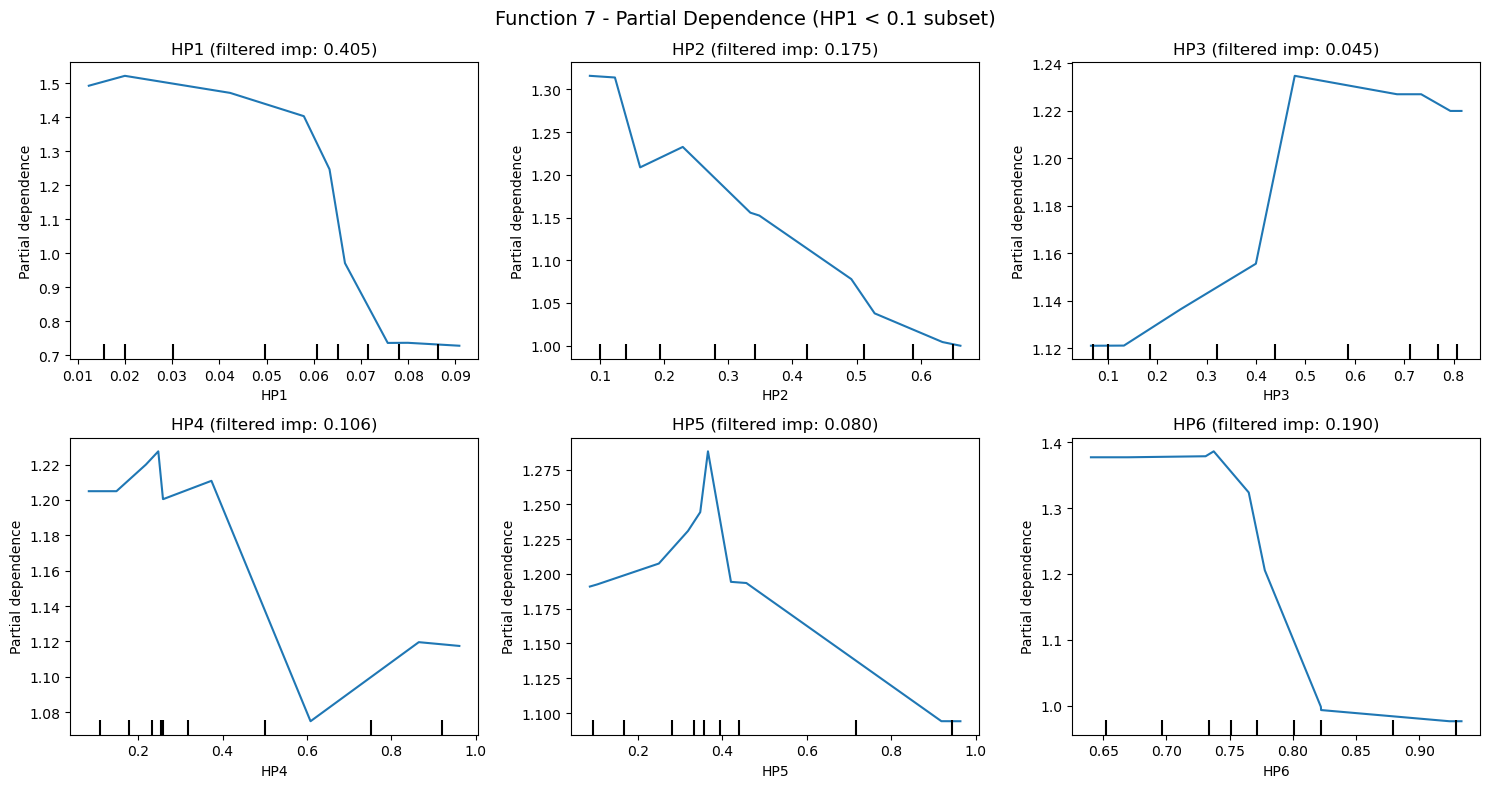

In [57]:
# Step 4: plot partial dependence for all 6 features on the HP1<0.1 filtered RF,
#  to visualise each hyperparameter's marginal effect once HP1's dominance is removed.

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    PartialDependenceDisplay.from_estimator(rf_filtered, filtered_inputs,
                                             features=[i],
                                             feature_names=feature_names, ax=ax)
    ax.set_title(f'{feature_names[i]} (filtered imp: {rf_filtered.feature_importances_[i]:.3f})')
plt.suptitle('Function 7 - Partial Dependence (HP1 < 0.1 subset)', fontsize=14)
plt.tight_layout()
plt.show()

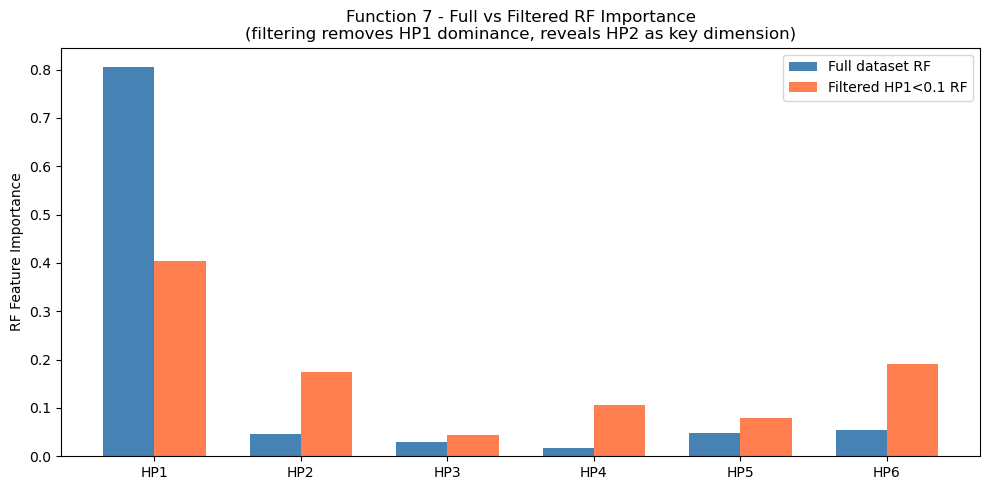

In [58]:
# Step 5: bar chart comparing full-dataset vs HP1-filtered RF importance side by side -- 
# makes the HP2 effect (hidden by HP1 in the full dataset) visually obvious.

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(6)
width_bar = 0.35
ax.bar(x_pos - width_bar/2, rf_full.feature_importances_, width_bar, label='Full dataset RF', color='steelblue')
ax.bar(x_pos + width_bar/2, rf_filtered.feature_importances_, width_bar, label='Filtered HP1<0.1 RF', color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names)
ax.set_ylabel('RF Feature Importance')
ax.set_title('Function 7 - Full vs Filtered RF Importance\n(filtering removes HP1 dominance, reveals HP2 as key dimension)')
ax.legend()
plt.tight_layout()
plt.show()

**Reflection:** next time I would compute permutation importance and SHAP alongside impurity importance from the very first RF fit, rather than treating them as a later validation step, so a misleading impurity ranking would be caught before it shapes the whole filtering pipeline.

# # Function 8, Unspecified field, 8D array, 40 original samples - Week 8

**Problem statement:** Maximise an unspecified 8D objective using an MC-Dropout neural network for both prediction and uncertainty, with kappa adapted from a measured leave-one-out calibration ratio, and candidates concentrated via SHAP-weighted perturbations around the current best point.

In [59]:
# =============================================================================
# Function 8, Unspecified field, 8D array, 40 original samples
# =============================================================================
# Previous weeks
# W3: Pipeline (a) combines partial exploration (free dimensions) with strong exploitation (pinned dimensions); 
#     Pipeline (b) is almost entirely exploitation-focused.
# W4: GP (ARD Matérn) UCB (κ = 2.0) + MLP regressor (50/50 blend)
# W5: MC-Dropout MLP (2 hidden layers, dropout active during inference with 50 stochastic forward passes); acquisition = UCB (κ = 3.0)
# W6: Dropout MLP (8→24→24→1); Standard scaling; UCB via MC-dropout uncertainty
# W7: MC-Dropout MLP; Dropout = 0.2; hidden units = 24; UCB κ = 1.7; SHAP-scaled noise; 
#     HAP-informed candidate generation to guide exploration

# change: Increase dropout to 0.25 and dynamically adjust UCB exploration 
#         use empirical calibration ratios to resolve neural network overconfidence.

print("\n" + "=" * 60)
print("Function 8 - Week 8")
print("=" * 60)
# Step 1: load the original samples and append every previously queried
f8_inputs  = np.load('initial_data/function_8/initial_inputs.npy')
f8_outputs = np.load('initial_data/function_8/initial_outputs.npy')

prev_queries_F8 = np.array([
    [0.034736, 0.033935, 0.577646, 0.735810, 0.807192, 0.026536, 0.72178, 0.629862],     #W2
    [0.019981, 0.000000, 0.999999, 0.000000, 0.448273, 0.855526, 0.446219, 0.931836],    #W3
    [0.035148, 0.000000, 0.018976, 0.000000, 0.999999, 0.361194, 0.007310, 0.000000],    #W4
    [0.040725, 0.748531, 0.178080, 0.981020, 0.988831, 0.993927, 0.013038, 0.216952],    #W5
    [0.060495, 0.027090, 0.006185, 0.132068, 0.160719, 0.354431, 0.001361, 0.931902],    #W6
    [0.000000, 0.009147, 0.046571, 0.113147, 0.150211, 0.340739, 0.038068, 0.928497],    #W7
])
prev_outputs_F8 = np.array([8.26488,                    #W2
                            7.35099,                    #W3
                            9.76008,                    #W4
                            8.590830,                   #W5
                            9.619999,                   #W6
                            9.638210,                   #W7
                           ])

all_inputs_F8  = np.vstack([f8_inputs, prev_queries_F8])
all_outputs_F8 = np.hstack([f8_outputs, prev_outputs_F8])

print(f"Total points: {len(all_outputs_F8)}, best: {all_outputs_F8.max():.4f}")


Function 8 - Week 8
Total points: 46, best: 9.7601


In [60]:
# Step 2: standardise inputs/outputs (neural nets train much better on scaled data) and
#  define a small MLP with dropout layers -- dropout stays active at prediction time (see mc_predict)
#  to give Monte-Carlo uncertainty estimates. Dropout rate is 0.25, raised from
#  an initial 0.20 for better calibration (see Step 4).

scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_sc = scaler_x.fit_transform(all_inputs_F8)
Y_sc = scaler_y.fit_transform(all_outputs_F8.reshape(-1, 1)).ravel()

X_tensor = torch.tensor(X_sc, dtype=torch.float32)
Y_tensor = torch.tensor(Y_sc, dtype=torch.float32).unsqueeze(1)

# MLP: hidden=24, dropout=0.25 (increased from 0.2 for better calibration)
class DropoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

In [61]:
# Step 3: leave-one-out calibration check -- for every held-out point,
# retrain a fresh model on the rest, predict the held-out point with MC Dropout,
# and record the absolute error and the model's own uncertainty (sigma). 
# Comparing error to sigma across all points tells us whether the model's 
# uncertainty estimates are trustworthy (calibrated) or over/under- confident.

loo_errors = []
loo_sigmas = []

for i in range(len(all_outputs_F8)):
    X_train_loo = np.delete(all_inputs_F8, i, axis=0)
    y_train_loo = np.delete(all_outputs_F8, i)
    X_test_loo  = all_inputs_F8[i:i+1]
    y_test_loo  = all_outputs_F8[i]

    sx_loo = StandardScaler()
    sy_loo = StandardScaler()
    X_tr_sc_loo = sx_loo.fit_transform(X_train_loo)
    y_tr_sc_loo = sy_loo.fit_transform(y_train_loo.reshape(-1, 1)).ravel()
    X_te_sc_loo = sx_loo.transform(X_test_loo)

    X_tr_tensor = torch.tensor(X_tr_sc_loo, dtype=torch.float32)
    Y_tr_tensor = torch.tensor(y_tr_sc_loo, dtype=torch.float32).unsqueeze(1)
    X_te_tensor = torch.tensor(X_te_sc_loo, dtype=torch.float32)

    torch.manual_seed(42)
    model_loo     = DropoutMLP(input_dim=8, hidden_dim=24, dropout_rate=0.25)
    optimiser_loo = torch.optim.Adam(model_loo.parameters(), lr=1e-3)

    model_loo.train()
    for epoch in range(1000):
        optimiser_loo.zero_grad()
        loss_loo = nn.MSELoss()(model_loo(X_tr_tensor), Y_tr_tensor)
        loss_loo.backward()
        optimiser_loo.step()

    mu_sc_loo, sigma_sc_loo = mc_predict(model_loo, X_te_tensor, n_passes=50)
    mu_loo    = sy_loo.inverse_transform(mu_sc_loo.reshape(-1, 1)).ravel()[0]
    sigma_loo = np.atleast_1d(sigma_sc_loo)[0] * sy_loo.scale_[0]

    loo_errors.append(abs(mu_loo - y_test_loo))
    loo_sigmas.append(sigma_loo)

loo_errors = np.array(loo_errors)
loo_sigmas = np.array(loo_sigmas)

In [62]:
# Step 4: turn the LOO calibration into an adaptive kappa -- 
# the ratio of mean |error| to mean predicted sigma tells us how much 
# to scale kappa so that UCB's uncertainty term reflects the model's *actual* measured error,
# not just its raw (possibly over/under-confident) sigma. 
# Then train the final model on all available data.

kappa_base = 1.7
cal_ratio  = loo_errors.mean() / loo_sigmas.mean()
kappa_F8      = kappa_base * cal_ratio

print(f"\nLOO Calibration (dropout=0.25):")
print(f"  mean |error|:        {loo_errors.mean():.4f}")
print(f"  std  |error|:        {loo_errors.std():.4f}")
print(f"  max  |error|:        {loo_errors.max():.4f}")
print(f"  mean sigma (LOO):    {loo_sigmas.mean():.4f}")
print(f"  ratio (error/sigma): {cal_ratio:.3f}  (1.0 = perfect calibration)")
print(f"  kappa (adaptive):    {kappa_F8:.2f}")

# train final model
torch.manual_seed(42)
model     = DropoutMLP(input_dim=8, hidden_dim=24, dropout_rate=0.25)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

model.train()
for epoch in range(1000):
    optimiser.zero_grad()
    pred = model(X_tensor)
    loss = loss_fn(pred, Y_tensor)
    loss.backward()
    optimiser.step()

print(f"Training loss (final): {loss.item():.4f}")


LOO Calibration (dropout=0.25):
  mean |error|:        0.3076
  std  |error|:        0.3176
  max  |error|:        1.2827
  mean sigma (LOO):    0.2759
  ratio (error/sigma): 1.115  (1.0 = perfect calibration)
  kappa (adaptive):    1.90
Training loss (final): 0.0551


  0%|          | 0/46 [00:00<?, ?it/s]

C:\Users\mayzu\AppData\Local\Temp\ipykernel_34040\63643803.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_F8, X_sc,


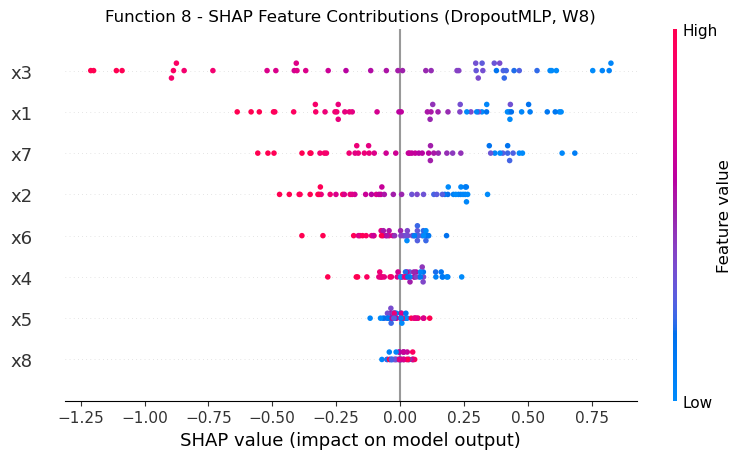

In [63]:
# Step 5: use SHAP (KernelExplainer, model-agnostic) on 
# the trained MLP to see which of the 8 inputs it relies on most.

model.eval()

def mlp_predict(X_np):
    """Wrapper for SHAP -- takes numpy array, returns numpy predictions."""
    X_t = torch.tensor(X_np, dtype=torch.float32)
    with torch.no_grad():
        preds = model(X_t).squeeze().numpy()
    return np.atleast_1d(preds)

background = X_sc[np.random.choice(len(X_sc), size=20, replace=False)]
explainer  = shap.KernelExplainer(mlp_predict, background)
shap_values_F8 = explainer.shap_values(X_sc, nsamples=100)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_F8, X_sc,
                  feature_names=[f'x{i+1}' for i in range(8)], show=False)
plt.title('Function 8 - SHAP Feature Contributions (DropoutMLP, W8)')
plt.tight_layout()
plt.show()

In [64]:
# Step 6: normalise the SHAP importances to [0, 1] and
#  identify the "refinement anchor" (W1) -- the best point observed so far -- 
# which the candidate pools below will be built around.

model.train()

shap_importance = np.abs(shap_values_F8).mean(axis=0)
shap_importance = shap_importance / shap_importance.max()

print("\nSHAP-derived importance (normalised):")
for i in range(8):
    print(f"  x{i+1}: {shap_importance[i]:.3f}")

w1_point = all_inputs_F8[np.argmax(all_outputs_F8)]
print(f"\nRefinement anchor (W1): {w1_point} -> {all_outputs_F8.max():.4f}")

np.random.seed(42)


SHAP-derived importance (normalised):
  x1: 0.662
  x2: 0.419
  x3: 1.000
  x4: 0.166
  x5: 0.076
  x6: 0.174
  x7: 0.530
  x8: 0.050

Refinement anchor (W1): [0.035148 0.       0.018976 0.       0.999999 0.361194 0.00731  0.      ] -> 9.7601


In [65]:
# Step 7: build two candidate pools around the refinement anchor. 
# Pool A perturbs every dimension with noise scaled by its SHAP importance -- 
#   more important (active) dimensions get larger jitter to encourage refinement,
#   less important ("settled") dimensions get tighter jitter. 
# Pool B is a structured sweep that fully varies x3 
#   (to probe a hypothesised non- monotonic effect) while jittering x1/x7 moderately and 
#   fixing the other dimensions at fixed/settled values.

pool_a_noise = np.random.randn(35000, 8)
for dim in range(8):
    if shap_importance[dim] > 0.5:  # active: x1, x3, x7
        pool_a_noise[:, dim] *= 0.05 + 0.03 * shap_importance[dim]
    else:  # settled: x2, x4, x5, x6, x8
        pool_a_noise[:, dim] *= 0.01 + 0.01 * shap_importance[dim]

pool_a = np.clip(w1_point + pool_a_noise, 0, 1)

pool_b = np.zeros((15000, 8))
pool_b[:, 2] = np.random.uniform(0, 1, 15000)          # x3: full sweep
pool_b[:, 0] = np.clip(w1_point[0] + np.random.randn(15000) * 0.15, 0, 1)  # x1: moderate noise
pool_b[:, 6] = np.clip(w1_point[6] + np.random.randn(15000) * 0.15, 0, 1)  # x7: moderate noise
pool_b[:, 1] = 0.0   # x2
pool_b[:, 3] = 0.0   # x4
pool_b[:, 4] = 1.0   # x5
pool_b[:, 5] = np.clip(w1_point[5] + np.random.randn(15000) * 0.02, 0, 1)  # x6: tight jitter
pool_b[:, 7] = 0.0   # x8

pool = np.vstack([pool_a, pool_b])
print(f"Candidate pool: {len(pool_a)} refinement + {len(pool_b)} x3-sweep = {len(pool)} total")

Candidate pool: 35000 refinement + 15000 x3-sweep = 50000 total


In [66]:
# Step 8: run MC-Dropout prediction (50 stochastic passes) 
# over the full candidate pool, score with UCB using 
# the calibration-adjusted kappa from Step 4, and select the Week 8 query.

print("=" * 60)
print("Function 8 - Week 8")
print("=" * 60)

pool_sc     = scaler_x.transform(pool)
pool_tensor = torch.tensor(pool_sc, dtype=torch.float32)

mu_sc, sigma_sc = mc_predict(model, pool_tensor, n_passes=50)

mu_F8    = scaler_y.inverse_transform(mu_sc.reshape(-1, 1)).ravel()
sigma_F8 = sigma_sc * scaler_y.scale_[0]


ucb_F8      = mu_F8 + kappa_F8 * sigma_F8
best_idx_F8 = np.argmax(ucb_F8)
query_F8    = pool[best_idx_F8]


pool_source = "Pool A (refinement)" if best_idx_F8 < len(pool_a) else "Pool B (x3-sweep)"

print(f"\nmu   range: {mu_F8.min():.3f} to {mu_F8.max():.3f}")
print(f"sigma range: {sigma_F8.min():.3f} to {sigma_F8.max():.3f}")
print(f"kappa*sigma range: {(kappa_F8*sigma_F8).min():.3f} to {(kappa_F8*sigma_F8).max():.3f}")

print(f"\nWeek 8 Query: {format_query(query_F8)}")
print(f"Source: {pool_source}")
print(f"MC mu: {mu_F8[best_idx_F8]:.4f}, sigma: {sigma_F8[best_idx_F8]:.4f}")
print(f"UCB:   {ucb_F8[best_idx_F8]:.4f}")

Function 8 - Week 8

mu   range: 8.024 to 9.963
sigma range: 0.192 to 0.547
kappa*sigma range: 0.364 to 1.036

Week 8 Query: 0.007786-0.000000-0.000000-0.000000-0.999999-0.368073-0.022080-0.018153
Source: Pool A (refinement)
MC mu: 9.8065, sigma: 0.5468
UCB:   10.8429


**Reflection:** next time I would validate the MC-Dropout calibration at more than one dropout rate before committing to 0.25, and track calibration ratio across weeks, since a single LOO check on one dropout value is a fairly thin basis for trusting the model's uncertainty estimates in 8D.